# Lib1 In-House Scratch HPO Best Models

Question: for the completed standardized Lib1 in-house full-orchestrator scratch HPO runs, which from-scratch models currently look best across promoter, intron, 3'UTR, 5'UTR, and enhancer, and do the new per-part HPO distributions behave like the earlier same-project HPO runs?

The primary analysis slice is restricted to completed registry rows from the full orchestrator sweeps launched on 2026-06-09/2026-06-10. Earlier same-project HPO rows remain useful as context but are not part of the completed-orchestrator model-selection slice.

Reads local sources only: `src/learn/run_registry/runs.csv`, `src/learn/run_registry/sweep_launches.csv`, derived learn-ready tables, local W&B config YAMLs, and the raw MattLee Lib1 CSVs under `opt_EU_learn_n_design/MattLee_lib1`.

Companion data-distribution notebook: [`../in_house_EDA/in_house_utr_eda_may2026.ipynb`](../in_house_EDA/in_house_utr_eda_may2026.ipynb). Use that notebook for deeper UTR assay/length/barcode EDA; use this notebook to connect those facts to scratch-HPO model selection and split diagnostics.


In [34]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError:
    yaml = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

cwd = Path.cwd().resolve()
ROOT = cwd
while ROOT.name != "boda2_EU" and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if ROOT.name != "boda2_EU":
    if (cwd / "boda2_EU").exists():
        ROOT = cwd / "boda2_EU"
    else:
        raise RuntimeError("Could not find boda2_EU repo root from current working directory")

REPO = ROOT.parent
LEARN = ROOT / "src" / "learn"
RUN_REGISTRY = LEARN / "run_registry"
MATTLEE = REPO / "opt_EU_learn_n_design" / "MattLee_lib1"

ROOT, REPO, LEARN


(PosixPath('/home/minhang/synBio_AL/boda2_EU'),
 PosixPath('/home/minhang/synBio_AL'),
 PosixPath('/home/minhang/synBio_AL/boda2_EU/src/learn'))

## Length And Dataset Fact Check

This cell verifies the central premise: in-house Lib1 active-part lengths do not match the public/legacy sources that seeded earlier pretraining decisions. It also keeps the promoter nuance visible: the current scratch branch is `allvalid` and pads to 51 nt, even though the modal insert is 50 nt. In the length-bin plot, each point is one observed sequence length; promoter has several points because the learn-ready all-valid table intentionally retains the shorter valid inserts instead of collapsing to modal50 only.


In [35]:
def length_counts(path, column, sep=",", filter_x=True):
    df = pd.read_csv(path, sep=sep, usecols=[column], low_memory=False)
    seqs = df[column].dropna().astype(str)
    if filter_x:
        seqs = seqs[seqs.ne("x")]
    counts = seqs.str.len().value_counts().sort_index()
    return counts

length_specs = [
    ("current_promoter_raw", MATTLEE / "promoters" / "L1_final_fastqs1-5_sublibrary_Promoter_subset.csv", "Promoter", ","),
    ("current_promoter_learn_ready", LEARN / "derived_data" / "promoter" / "bashor_in_house" / "lib1_promoter_allvalid_fastqs1_5__learn_ready.tsv", "Promoter", "\t"),
    ("current_intron_modal80", LEARN / "derived_data" / "introns" / "bashor_in_house" / "lib1_intron_modal80_fastqs1_5__learn_ready.tsv", "Intron", "\t"),
    ("current_threeprime_modal100", LEARN / "derived_data" / "utr3" / "bashor_in_house" / "lib1_threeprime_modal100_fastqs1_5__learn_ready.tsv", "ThreePrime", "\t"),
    ("current_fiveprime_raw_reference", MATTLEE / "FivePrimes" / "L1_final_fastqs1-5_sublibrary_FivePrime_subset.csv", "FivePrime", ","),
    ("current_fiveprime_modal50", LEARN / "derived_data" / "utr5" / "bashor_in_house" / "lib1_fiveprime_modal50_fastqs1_5__learn_ready.tsv", "FivePrime", "\t"),
    ("current_enhancer_no_flank_hq8", LEARN / "derived_data" / "enhancer" / "bashor_in_house" / "lib1_fastqs1_5_0filtered_out__learn_ready.tsv", "Enhancers", "\t"),
    ("prior_seelig_a5ss", REPO / "opt_EU_learn_n_design" / "introns" / "seelig_2015" / "A5SS_scalar_targets.csv", "seq", ","),
    ("prior_hani_threeprime", REPO / "opt_EU_learn_n_design" / "utr_hani_2025" / "processed_utr_data" / "3UTR_lib1_branched_observed_heads.csv", "seq", ","),
    ("prior_legacy_e7_e30_promoter", LEARN / "derived_data" / "promoter" / "legacy_in_house_e7_e30" / "legacy_e7_e30_originals_train90000_val_test.csv", "sequence", ","),
]

rows = []
for label, path, col, sep in length_specs:
    counts = length_counts(path, col, sep=sep)
    n = int(counts.sum())
    modal_len = int(counts.idxmax())
    rows.append({
        "dataset": label,
        "n_rows": n,
        "min_len": int(counts.index.min()),
        "modal_len": modal_len,
        "modal_count": int(counts.loc[modal_len]),
        "modal_fraction": float(counts.loc[modal_len] / n),
        "max_len": int(counts.index.max()),
    })

length_summary = pd.DataFrame(rows)
display(length_summary)

detail_labels = ["current_promoter_learn_ready", "current_intron_modal80", "current_threeprime_modal100", "current_fiveprime_modal50", "current_enhancer_no_flank_hq8", "prior_seelig_a5ss", "prior_hani_threeprime", "prior_legacy_e7_e30_promoter"]
detail_rows = []
for label, path, col, sep in length_specs:
    if label not in detail_labels:
        continue
    counts = length_counts(path, col, sep=sep)
    for length, count in counts.items():
        detail_rows.append({"dataset": label, "length": int(length), "count": int(count)})
length_detail = pd.DataFrame(detail_rows)
display(length_detail)


,dataset,n_rows,min_len,modal_len,modal_count,modal_fraction,max_len
0,current_promoter_raw,7893,41,50,7774,0.984923,51
1,current_promoter_learn_ready,7893,41,50,7774,0.984923,51
2,current_intron_modal80,7848,80,80,7848,1.000000,80
3,current_threeprime_modal100,6845,100,100,6845,1.000000,100
4,current_fiveprime_raw_reference,8460,40,50,8331,0.984752,51
5,current_fiveprime_modal50,8331,50,50,8331,1.000000,50
6,current_enhancer_no_flank_hq8,4788,1,200,4030,0.841688,211
7,prior_seelig_a5ss,265044,101,101,265044,1.000000,101
8,prior_hani_threeprime,28426,240,240,28426,1.000000,240
9,prior_legacy_e7_e30_promoter,105591,84,84,105591,1.000000,84


,dataset,length,count
0,current_promoter_learn_ready,41,2
1,current_promoter_learn_ready,42,3
2,current_promoter_learn_ready,43,1
3,current_promoter_learn_ready,44,2
4,current_promoter_learn_ready,45,4
...,...,...,...
64,current_enhancer_no_flank_hq8,201,35
65,current_enhancer_no_flank_hq8,211,1
66,prior_seelig_a5ss,101,265044
67,prior_hani_threeprime,240,28426


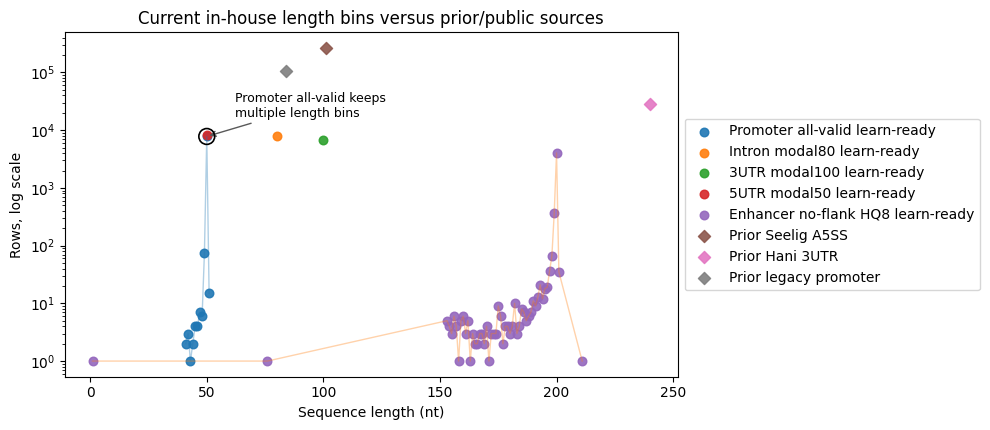

In [36]:
length_plot_labels = {
    "current_promoter_learn_ready": "Promoter all-valid learn-ready",
    "current_intron_modal80": "Intron modal80 learn-ready",
    "current_threeprime_modal100": "3UTR modal100 learn-ready",
    "current_fiveprime_modal50": "5UTR modal50 learn-ready",
    "current_enhancer_no_flank_hq8": "Enhancer no-flank HQ8 learn-ready",
    "prior_seelig_a5ss": "Prior Seelig A5SS",
    "prior_hani_threeprime": "Prior Hani 3UTR",
    "prior_legacy_e7_e30_promoter": "Prior legacy promoter",
}

fig, ax = plt.subplots(figsize=(10, 4.4))
plot_df = length_detail[length_detail["dataset"].isin(detail_labels)].copy()
for dataset, part in plot_df.groupby("dataset", sort=False):
    part = part.sort_values("length")
    is_current = dataset.startswith("current_")
    label = length_plot_labels.get(dataset, dataset)
    marker = "o" if is_current else "D"
    if len(part) > 1:
        ax.plot(part["length"], part["count"], alpha=0.35, linewidth=1)
    ax.scatter(part["length"], part["count"], label=label, s=38, marker=marker, alpha=0.9)

promoter_bins = plot_df[plot_df["dataset"].eq("current_promoter_learn_ready")]
if not promoter_bins.empty:
    modal_row = promoter_bins.loc[promoter_bins["count"].idxmax()]
    ax.scatter(
        [modal_row["length"]], [modal_row["count"]],
        s=130, facecolors="none", edgecolors="black", linewidths=1.2, zorder=5,
    )
    ax.annotate(
        "Promoter all-valid keeps\nmultiple length bins",
        xy=(modal_row["length"], modal_row["count"]),
        xytext=(62, modal_row["count"] * 2.2),
        arrowprops={"arrowstyle": "->", "color": "0.35", "linewidth": 1},
        fontsize=9,
    )

ax.set_yscale("log")
ax.set_xlabel("Sequence length (nt)")
ax.set_ylabel("Rows, log scale")
ax.set_title("Current in-house length bins versus prior/public sources")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
fig.tight_layout()


## Scratch HPO Registry Summary

Use validation-first ranking for promotion. The primary model-selection pool is restricted to completed rows from the full orchestrator sweeps across promoter, intron, 3'UTR, 5'UTR, and enhancer. Earlier same-project HPO rows are retained as a separate comparison cohort so we can ask whether the full orchestrator behaved wildly differently from the prior HPO attempts.


In [37]:
FULL_ORCHESTRATOR_START = "2026-06-09T23:44:00"
ORCHESTRATOR_FINISHED_SWEEP_IDS = {
    "n2tgydi6",  # promoter ResNet1D, full orchestrator
    "vi17zxcm",  # promoter BassetVL, full orchestrator
    "5b0njbjz",  # intron ResNet1D, full orchestrator
    "bnyvegba",  # 3UTR ResNet1D fp32, full orchestrator
    "nhoh1zuw",  # 3UTR UTR_BassetVL fp32, full orchestrator
    "87uud4bc",  # 5UTR ResNet1D fp32, full orchestrator
    "hs7moccj",  # 5UTR UTR_BassetVL fp32, full orchestrator
    "az1dlbv1",  # enhancer ResNet1D fp32, full orchestrator
    "haf7rbbj",  # enhancer BassetVL fp32, full orchestrator
}
ORCHESTRATOR_IN_PROGRESS_SWEEP_IDS = set()
FINISHED_ORCHESTRATOR_REGIONS = ("Promoter", "Intron", "3UTR", "5UTR", "Enhancer")
ORCHESTRATOR_ANALYSIS_SCOPES = ("orchestrator_complete",)
COMPARISON_SCOPES = ("orchestrator_complete", "prior_same_project")

project_rows = [
    {
        "logger_project": "promoter__bashor_in_house__lib1_allvalid__scratch__resnet1d",
        "cre_region": "Promoter",
        "architecture": "ResNet1D",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "promoter",
    },
    {
        "logger_project": "promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl",
        "cre_region": "Promoter",
        "architecture": "BassetVL",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "promoter",
    },
    {
        "logger_project": "introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d",
        "cre_region": "Intron",
        "architecture": "ResNet1D",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "intron",
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d",
        "cre_region": "3UTR",
        "architecture": "ResNet1D",
        "run_family": "legacy precision diagnostic",
        "base_selection_scope": "audit_only",
        "orchestrator_part": None,
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32",
        "cre_region": "3UTR",
        "architecture": "ResNet1D",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "utr3",
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_fp32",
        "cre_region": "3UTR",
        "architecture": "BassetVL",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "utr3",
    },
    {
        "logger_project": "utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_focused_rc_factorial_fp32",
        "cre_region": "3UTR",
        "architecture": "BassetVL",
        "run_family": "focused RC grid",
        "base_selection_scope": "followup_grid",
        "orchestrator_part": None,
    },
    {
        "logger_project": "utr5__bashor_in_house__fiveprime_modal50__scratch__resnet1d_fp32",
        "cre_region": "5UTR",
        "architecture": "ResNet1D",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "utr5",
    },
    {
        "logger_project": "utr5__bashor_in_house__fiveprime_modal50__scratch__utr_bassetvl_fp32",
        "cre_region": "5UTR",
        "architecture": "BassetVL",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "utr5",
    },
    {
        "logger_project": "enhancer__bashor_in_house__no_flank_hq8__scratch__resnet1d_fp32",
        "cre_region": "Enhancer",
        "architecture": "ResNet1D",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "enhancer",
    },
    {
        "logger_project": "enhancer__bashor_in_house__no_flank_hq8__scratch__bassetvl_fp32",
        "cre_region": "Enhancer",
        "architecture": "BassetVL",
        "run_family": "standardized scratch",
        "base_selection_scope": "standard_project",
        "orchestrator_part": "enhancer",
    },
]

project_table = pd.DataFrame(project_rows)
project_table["project_label"] = project_table["cre_region"] + " " + project_table["architecture"]
project_table["project_detail"] = np.where(
    project_table["run_family"].eq("standardized scratch"),
    project_table["project_label"],
    project_table["project_label"] + " (" + project_table["run_family"] + ")",
)
display(project_table)

runs = pd.read_csv(RUN_REGISTRY / "runs.csv", low_memory=False)
sweep_launches = pd.read_csv(RUN_REGISTRY / "sweep_launches.csv", low_memory=False)
for col in ["num_agents", "runs_per_agent"]:
    if col in sweep_launches.columns:
        sweep_launches[col] = pd.to_numeric(sweep_launches[col], errors="coerce")

subset = runs.merge(project_table, on="logger_project", how="inner")
subset["wandb_sweep_id"] = subset["wandb_sweep_id"].astype(str)

metric_cols = [
    "best_metric_value", "val_loss", "val_r2", "val_pearson", "val_spearman",
    "test_loss", "test_r2", "test_pearson", "test_spearman",
    "train_loss", "train_r2", "train_pearson", "train_spearman",
    "val_pearson_r2", "val_cod_r2", "val_mse", "test_pearson_r2", "test_cod_r2", "test_mse",
    "train_pearson_r2", "train_cod_r2", "train_mse",
]
for col in metric_cols:
    if col in subset.columns:
        subset[col] = pd.to_numeric(subset[col], errors="coerce")

subset["invalid_pearson"] = subset[["val_pearson", "test_pearson", "train_pearson"]].abs().gt(1).any(axis=1)
subset["health"] = np.where(subset["invalid_pearson"], "invalid_pearson", "ok")
subset["completed"] = subset["status"].eq("completed")
subset["selection_ready"] = (
    subset["completed"]
    & subset["health"].eq("ok")
    & subset["val_pearson"].notna()
    & subset["test_pearson"].notna()
)

standard_project_mask = subset["orchestrator_part"].notna()
finished_mask = subset["wandb_sweep_id"].isin(ORCHESTRATOR_FINISHED_SWEEP_IDS)
in_progress_mask = subset["wandb_sweep_id"].isin(ORCHESTRATOR_IN_PROGRESS_SWEEP_IDS)
prior_same_project_mask = standard_project_mask & ~(finished_mask | in_progress_mask)

subset["selection_scope"] = np.select(
    [finished_mask, in_progress_mask, prior_same_project_mask],
    ["orchestrator_complete", "orchestrator_in_progress", "prior_same_project"],
    default=subset["base_selection_scope"],
)
subset["source_cohort"] = np.select(
    [finished_mask, in_progress_mask, prior_same_project_mask],
    ["Full orchestrator finished", "Full orchestrator in progress", "Earlier same-project HPO"],
    default="Other audit/follow-up",
)

completed_subset = subset[subset["completed"]].copy()
selection_subset = completed_subset[completed_subset["selection_scope"].isin(ORCHESTRATOR_ANALYSIS_SCOPES)].copy()
prior_same_project_subset = completed_subset[completed_subset["selection_scope"].eq("prior_same_project")].copy()
comparison_subset = completed_subset[completed_subset["selection_scope"].isin(COMPARISON_SCOPES)].copy()

region_order = {"Promoter": 0, "Intron": 1, "3UTR": 2, "5UTR": 3, "Enhancer": 4}
architecture_order = {"ResNet1D": 0, "BassetVL": 1}
cohort_order = {"Earlier same-project HPO": 0, "Full orchestrator finished": 1, "Full orchestrator in progress": 2, "Other audit/follow-up": 3}

launch_counts = subset.groupby("wandb_sweep_id").agg(
    registry_rows=("run_id", "nunique"),
    completed_rows=("completed", "sum"),
    selection_ready_rows=("selection_ready", "sum"),
).reset_index()

orchestrator_sweep_table = sweep_launches[
    sweep_launches["sweep_id"].astype(str).isin(ORCHESTRATOR_FINISHED_SWEEP_IDS | ORCHESTRATOR_IN_PROGRESS_SWEEP_IDS)
].copy()
orchestrator_sweep_table["expected_runs"] = orchestrator_sweep_table["num_agents"] * orchestrator_sweep_table["runs_per_agent"]
orchestrator_sweep_table = orchestrator_sweep_table.merge(
    launch_counts,
    left_on="sweep_id",
    right_on="wandb_sweep_id",
    how="left",
).drop(columns=["wandb_sweep_id"])
orchestrator_sweep_table[["registry_rows", "completed_rows", "selection_ready_rows"]] = orchestrator_sweep_table[["registry_rows", "completed_rows", "selection_ready_rows"]].fillna(0).astype(int)
orchestrator_sweep_table["full_orchestrator_state"] = np.where(
    orchestrator_sweep_table["sweep_id"].isin(ORCHESTRATOR_FINISHED_SWEEP_IDS),
    "finished_included",
    "in_progress_excluded",
)
display(orchestrator_sweep_table[[
    "launched_at", "task_family", "wandb_project", "sweep_id", "full_orchestrator_state",
    "registry_rows", "completed_rows", "selection_ready_rows", "expected_runs", "config_path",
]])

summary = subset.groupby(
    ["source_cohort", "selection_scope", "cre_region", "architecture", "run_family", "orchestrator_part", "logger_project", "model_module"],
    dropna=False,
).agg(
    n_runs=("run_id", "nunique"),
    completed=("completed", "sum"),
    completed_ok=("selection_ready", "sum"),
    invalid_runs=("invalid_pearson", "sum"),
    val_pearson_max=("val_pearson", "max"),
    val_pearson_mean=("val_pearson", "mean"),
    test_pearson_max=("test_pearson", "max"),
    test_pearson_mean=("test_pearson", "mean"),
    latest_registry_timestamp=("timestamp", "max"),
    sweep_ids=("wandb_sweep_id", lambda s: ", ".join(sorted(set(map(str, s.dropna()))))),
    best_metric_names=("best_metric_name", lambda s: ", ".join(sorted(set(map(str, s.dropna()))))),
).reset_index()
summary["region_order"] = summary["cre_region"].map(region_order).fillna(99)
summary["architecture_order"] = summary["architecture"].map(architecture_order).fillna(99)
summary["cohort_order"] = summary["source_cohort"].map(cohort_order).fillna(99)
summary = summary.sort_values(["cohort_order", "region_order", "architecture_order", "run_family", "logger_project"]).drop(columns=["cohort_order", "region_order", "architecture_order"])
display(summary)

display(selection_subset.groupby(["cre_region", "architecture", "logger_project"], dropna=False).agg(
    finished_completed_rows=("run_id", "nunique"),
    val_pearson_max=("val_pearson", "max"),
    test_pearson_max=("test_pearson", "max"),
    latest_registry_timestamp=("timestamp", "max"),
).reset_index().sort_values(["cre_region", "architecture"]))


,logger_project,cre_region,architecture,run_family,base_selection_scope,orchestrator_part,project_label,project_detail
0,promoter__bashor_in_house__lib1_allvalid__scra...,Promoter,ResNet1D,standardized scratch,standard_project,promoter,Promoter ResNet1D,Promoter ResNet1D
1,promoter__bashor_in_house__lib1_allvalid__scra...,Promoter,BassetVL,standardized scratch,standard_project,promoter,Promoter BassetVL,Promoter BassetVL
2,introns__bashor_in_house__lib1_intron_modal80_...,Intron,ResNet1D,standardized scratch,standard_project,intron,Intron ResNet1D,Intron ResNet1D
3,utr3__bashor_in_house__threeprime_modal100__sc...,3UTR,ResNet1D,legacy precision diagnostic,audit_only,None,3UTR ResNet1D,3UTR ResNet1D (legacy precision diagnostic)
4,utr3__bashor_in_house__threeprime_modal100__sc...,3UTR,ResNet1D,standardized scratch,standard_project,utr3,3UTR ResNet1D,3UTR ResNet1D
5,utr3__bashor_in_house__threeprime_modal100__sc...,3UTR,BassetVL,standardized scratch,standard_project,utr3,3UTR BassetVL,3UTR BassetVL
6,utr3__bashor_in_house__threeprime_modal100__sc...,3UTR,BassetVL,focused RC grid,followup_grid,None,3UTR BassetVL,3UTR BassetVL (focused RC grid)
7,utr5__bashor_in_house__fiveprime_modal50__scra...,5UTR,ResNet1D,standardized scratch,standard_project,utr5,5UTR ResNet1D,5UTR ResNet1D
8,utr5__bashor_in_house__fiveprime_modal50__scra...,5UTR,BassetVL,standardized scratch,standard_project,utr5,5UTR BassetVL,5UTR BassetVL
9,enhancer__bashor_in_house__no_flank_hq8__scrat...,Enhancer,ResNet1D,standardized scratch,standard_project,enhancer,Enhancer ResNet1D,Enhancer ResNet1D


,launched_at,task_family,wandb_project,sweep_id,full_orchestrator_state,registry_rows,completed_rows,selection_ready_rows,expected_runs,config_path
0,2026-06-09T23:44:57-05:00,promoter,promoter__bashor_in_house__lib1_allvalid__scra...,n2tgydi6,finished_included,126,126,126,128,configs/promoter/bashor_in_house/resnet1d/lib1...
1,2026-06-09T23:44:59-05:00,promoter,promoter__bashor_in_house__lib1_allvalid__scra...,vi17zxcm,finished_included,128,128,128,128,configs/promoter/bashor_in_house/promoter_bass...
2,2026-06-10T04:19:43-05:00,introns,introns__bashor_in_house__lib1_intron_modal80_...,5b0njbjz,finished_included,126,126,126,128,configs/introns/bashor_in_house/resnet1d/lib1_...
3,2026-06-10T06:06:24-05:00,utr3,utr3__bashor_in_house__threeprime_modal100__sc...,bnyvegba,finished_included,127,127,127,128,configs/utr3/bashor_in_house/resnet1d/lib1_thr...
4,2026-06-10T06:06:26-05:00,utr3,utr3__bashor_in_house__threeprime_modal100__sc...,nhoh1zuw,finished_included,128,128,128,128,configs/utr3/bashor_in_house/utr_bassetvl/lib1...
5,2026-06-10T09:52:03-05:00,utr5,utr5__bashor_in_house__fiveprime_modal50__scra...,87uud4bc,finished_included,128,128,128,128,configs/utr5/bashor_in_house/resnet1d/lib1_fiv...
6,2026-06-10T09:52:05-05:00,utr5,utr5__bashor_in_house__fiveprime_modal50__scra...,hs7moccj,finished_included,128,128,128,128,configs/utr5/bashor_in_house/utr_bassetvl/lib1...
7,2026-06-10T16:18:35-05:00,enhancer,enhancer__bashor_in_house__no_flank_hq8__scrat...,az1dlbv1,finished_included,128,128,128,128,configs/enhancer/bashor_in_house/resnet1d/lib1...
8,2026-06-10T16:18:37-05:00,enhancer,enhancer__bashor_in_house__no_flank_hq8__scrat...,haf7rbbj,finished_included,127,127,127,128,configs/enhancer/bashor_in_house/bassetvl/lib1...


,source_cohort,selection_scope,cre_region,architecture,run_family,orchestrator_part,logger_project,model_module,n_runs,completed,completed_ok,invalid_runs,val_pearson_max,val_pearson_mean,test_pearson_max,test_pearson_mean,latest_registry_timestamp,sweep_ids,best_metric_names
8,Earlier same-project HPO,prior_same_project,Promoter,ResNet1D,standardized scratch,promoter,promoter__bashor_in_house__lib1_allvalid__scra...,ResNet1DRegressor,34,34,34,0,0.365454,0.292668,3.932220e-01,3.103122e-01,2026-06-09T10:55:01,s2diz4s6,val_pearson
7,Earlier same-project HPO,prior_same_project,Promoter,BassetVL,standardized scratch,promoter,promoter__bashor_in_house__lib1_allvalid__scra...,PromoterBassetVL,48,48,48,0,0.406872,0.352223,3.667765e-01,3.058774e-01,2026-06-09T13:55:43,xzw2b95t,val_pearson
6,Earlier same-project HPO,prior_same_project,Intron,ResNet1D,standardized scratch,intron,introns__bashor_in_house__lib1_intron_modal80_...,ResNet1DRegressor,32,32,32,0,0.602754,0.534280,7.182989e-01,6.560358e-01,2026-06-09T10:58:10,hv9bbdkt,val_pearson
1,Earlier same-project HPO,prior_same_project,3UTR,ResNet1D,standardized scratch,utr3,utr3__bashor_in_house__threeprime_modal100__sc...,ResNet1DRegressor,32,32,32,0,0.280072,0.133947,3.406695e-01,1.584512e-01,2026-06-08T19:10:43,p26ne4x3,val_pearson
0,Earlier same-project HPO,prior_same_project,3UTR,BassetVL,standardized scratch,utr3,utr3__bashor_in_house__threeprime_modal100__sc...,UTR_BassetVL,32,32,32,0,0.378506,0.176571,4.199174e-01,1.264307e-01,2026-06-08T19:28:31,k0g0eh19,val_pearson
3,Earlier same-project HPO,prior_same_project,5UTR,ResNet1D,standardized scratch,utr5,utr5__bashor_in_house__fiveprime_modal50__scra...,ResNet1DRegressor,64,64,64,0,0.482143,0.359242,4.869632e-01,3.679095e-01,2026-06-09T22:09:46,0ieyxjkk,val_pearson
2,Earlier same-project HPO,prior_same_project,5UTR,BassetVL,standardized scratch,utr5,utr5__bashor_in_house__fiveprime_modal50__scra...,UTR_BassetVL,64,64,64,0,0.531705,0.434945,4.577155e-01,3.728295e-01,2026-06-09T23:42:46,ba6t98l8,val_pearson
5,Earlier same-project HPO,prior_same_project,Enhancer,ResNet1D,standardized scratch,enhancer,enhancer__bashor_in_house__no_flank_hq8__scrat...,ResNet1DRegressor,2,2,2,0,0.242599,0.089902,1.018131e-01,5.199170e-02,2026-06-09T23:38:05,"xygpanfs, ygrpm8aq",val_pearson
4,Earlier same-project HPO,prior_same_project,Enhancer,BassetVL,standardized scratch,enhancer,enhancer__bashor_in_house__no_flank_hq8__scrat...,BassetVL,2,2,2,0,0.163564,0.083664,1.322400e-01,9.602726e-02,2026-06-09T23:42:28,"l3vhqano, tgr0zs27",val_pearson
17,Full orchestrator finished,orchestrator_complete,Promoter,ResNet1D,standardized scratch,promoter,promoter__bashor_in_house__lib1_allvalid__scra...,ResNet1DRegressor,126,126,126,0,0.387018,0.279129,3.851080e-01,2.930217e-01,2026-06-10T03:56:35,n2tgydi6,val_pearson


,cre_region,architecture,logger_project,finished_completed_rows,val_pearson_max,test_pearson_max,latest_registry_timestamp
0,3UTR,BassetVL,utr3__bashor_in_house__threeprime_modal100__sc...,128,0.335262,0.586879,2026-06-10T09:37:50
1,3UTR,ResNet1D,utr3__bashor_in_house__threeprime_modal100__sc...,127,0.455851,0.477185,2026-06-10T09:51:46
2,5UTR,BassetVL,utr5__bashor_in_house__fiveprime_modal50__scra...,128,0.538877,0.458869,2026-06-10T16:18:20
3,5UTR,ResNet1D,utr5__bashor_in_house__fiveprime_modal50__scra...,128,0.540936,0.498117,2026-06-10T13:40:50
4,Enhancer,BassetVL,enhancer__bashor_in_house__no_flank_hq8__scrat...,127,0.217002,0.227071,2026-06-10T19:06:28
5,Enhancer,ResNet1D,enhancer__bashor_in_house__no_flank_hq8__scrat...,128,0.269468,0.215067,2026-06-10T20:07:17
6,Intron,ResNet1D,introns__bashor_in_house__lib1_intron_modal80_...,126,0.613275,0.718182,2026-06-10T06:06:09
7,Promoter,BassetVL,promoter__bashor_in_house__lib1_allvalid__scra...,128,0.425197,0.391424,2026-06-10T04:19:30
8,Promoter,ResNet1D,promoter__bashor_in_house__lib1_allvalid__scra...,126,0.387018,0.385108,2026-06-10T03:56:35


In [38]:
def top_by_metric(df, metric, label, group_col="logger_project"):
    ok = df[df["selection_ready"] & df[metric].notna()].copy()
    top = ok.sort_values(metric, ascending=False).groupby(group_col, as_index=False).head(1)
    top.insert(0, "selection_view", label)
    return top

leaderboard = pd.concat([
    top_by_metric(selection_subset, "val_pearson", "validation_first"),
    top_by_metric(selection_subset, "test_pearson", "test_max_diagnostic"),
], ignore_index=True)

leader_cols = [
    "selection_view", "cre_region", "architecture", "run_family", "run_id", "run_name", "model_module", "best_epoch",
    "best_metric_name", "best_metric_value", "val_pearson", "test_pearson",
    "val_r2", "test_r2", "val_cod_r2", "test_cod_r2", "artifact_path",
]
display(leaderboard[leader_cols].sort_values(["cre_region", "architecture", "run_family", "selection_view"]))


,selection_view,cre_region,architecture,run_family,run_id,run_name,model_module,best_epoch,best_metric_name,best_metric_value,val_pearson,test_pearson,val_r2,test_r2,val_cod_r2,test_cod_r2,artifact_path
10,test_max_diagnostic,3UTR,BassetVL,standardized scratch,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,UTR_BassetVL,24,val_pearson,0.409130,0.282984,0.586879,0.080080,0.344427,0.043811,0.271224,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
6,validation_first,3UTR,BassetVL,standardized scratch,utc3cqzn,threeprime_modal100_utr_bassetvl_fp32_9mp1v3ff,UTR_BassetVL,50,val_pearson,0.458315,0.335262,0.281119,0.112401,0.079028,0.103881,0.078146,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
12,test_max_diagnostic,3UTR,ResNet1D,standardized scratch,39glhfll,threeprime_modal100_resnet1d_fp32_epve8bmt,ResNet1DRegressor,83,val_pearson,0.379558,0.353463,0.477185,0.124936,0.227705,0.078917,0.158600,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
3,validation_first,3UTR,ResNet1D,standardized scratch,8xcp9her,threeprime_modal100_resnet1d_fp32_7g4izye6,ResNet1DRegressor,80,val_pearson,0.573280,0.455851,0.085764,0.207800,0.007355,0.054843,-0.123699,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
13,test_max_diagnostic,5UTR,BassetVL,standardized scratch,a5zoy95n,lib1_fiveprime_modal50_utr_bassetvl_scratch_69...,UTR_BassetVL,156,val_pearson,0.453966,0.451856,0.458869,0.204174,0.210561,0.096331,0.155275,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
2,validation_first,5UTR,BassetVL,standardized scratch,n9lzq306,lib1_fiveprime_modal50_utr_bassetvl_scratch_0i...,UTR_BassetVL,151,val_pearson,0.540648,0.538877,0.344869,0.290389,0.118935,0.229501,0.065318,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
11,test_max_diagnostic,5UTR,ResNet1D,standardized scratch,yydnds86,lib1_fiveprime_modal50_resnet1d_scratch_tmrktxth,ResNet1DRegressor,178,val_pearson,0.468863,0.468385,0.498117,0.219384,0.248120,-2.610752,-3.586610,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
1,validation_first,5UTR,ResNet1D,standardized scratch,4a2z7obx,lib1_fiveprime_modal50_resnet1d_scratch_aqf8aku8,ResNet1DRegressor,161,val_pearson,0.545004,0.540936,0.367017,0.292611,0.134702,0.270994,0.107927,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
16,test_max_diagnostic,Enhancer,BassetVL,standardized scratch,f0e9s0ef,lib1_enhancer_no_flank_hq8_bassetvl_scratch_e8...,BassetVL,2,val_pearson,0.249753,0.195890,0.227071,0.038373,0.051561,-0.182152,-0.048275,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
8,validation_first,Enhancer,BassetVL,standardized scratch,rbdf02tt,lib1_enhancer_no_flank_hq8_bassetvl_scratch_rg...,BassetVL,62,val_pearson,0.240553,0.217002,0.136143,0.047090,0.018535,-0.010850,-0.221011,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...


## Best-Run Hyperparameters From Local W&B Configs

These configs are local W&B snapshots. If a run is missing here, either sync the W&B folder or fetch the config from W&B before making a final model card.


In [39]:
import re
from functools import lru_cache


def flatten_wandb_config(config):
    flat = {}
    for key, value in (config or {}).items():
        if str(key).startswith("_"):
            continue
        if isinstance(value, dict) and "value" in value:
            flat[key] = value["value"]
        else:
            flat[key] = value
    return flat


def parse_config_scalar(raw):
    raw = str(raw).strip()
    if raw in {"", "null", "None", "~"}:
        return None
    if raw.lower() == "true":
        return True
    if raw.lower() == "false":
        return False
    if raw.startswith("[") and raw.endswith("]"):
        inner = raw[1:-1].strip()
        if not inner:
            return []
        return [parse_config_scalar(part.strip()) for part in inner.split(",")]
    if (raw.startswith("'") and raw.endswith("'")) or (raw.startswith('"') and raw.endswith('"')):
        return raw[1:-1]
    try:
        return int(raw)
    except ValueError:
        pass
    try:
        return float(raw)
    except ValueError:
        return raw


def load_wandb_config_fallback(path):
    flat = {}
    current_key = None
    top_level = re.compile(r"^([A-Za-z0-9_./-]+):\s*(.*)$")
    value_line = re.compile(r"^  value:\s*(.*)$")
    with path.open() as fh:
        for line in fh:
            line = line.rstrip("\n")
            match = top_level.match(line)
            if match:
                key, rest = match.groups()
                current_key = None if key.startswith("_") else key
                if current_key and rest:
                    flat[current_key] = parse_config_scalar(rest)
                continue
            if current_key:
                match = value_line.match(line)
                if match:
                    flat[current_key] = parse_config_scalar(match.group(1))
    return flat


def build_config_path_index():
    index = {}
    for path in (LEARN / "wandb").glob("sweep-*/config-*.yaml"):
        run_id = path.stem.replace("config-", "")
        index.setdefault(run_id, []).append(path)
    for path in (LEARN / "wandb").glob("run-*/files/config.yaml"):
        run_dir = path.parents[1].name
        run_id = run_dir.split("-")[-1]
        index.setdefault(run_id, []).append(path)
    return index


CONFIG_PATHS_BY_RUN = build_config_path_index()


def rel_to_root(path):
    if path is None:
        return None
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


def normalize_bool(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        lowered = value.strip().lower()
        if lowered in {"true", "1", "yes", "y"}:
            return True
        if lowered in {"false", "0", "no", "n"}:
            return False
        return np.nan
    return bool(value)


@lru_cache(maxsize=None)
def load_run_config(run_id):
    candidates = CONFIG_PATHS_BY_RUN.get(str(run_id), [])
    if not candidates:
        return {}, None
    path = candidates[0]
    if yaml is not None:
        with path.open() as fh:
            return flatten_wandb_config(yaml.safe_load(fh)), path
    return load_wandb_config_fallback(path), path


hparam_keys = [
    "model_module", "input_len", "padded_seq_len", "padding_mode", "use_reverse_complements",
    "split_seed", "model_seed", "optimizer", "lr", "weight_decay", "scheduler", "batch_size", "precision",
    "stem_channels", "stem_kernel_size", "block_kernel_size", "dropout_p", "head_hidden_channels", "use_batch_norm",
    "conv1_channels", "conv1_kernel_size", "conv2_channels", "conv2_kernel_size", "conv3_channels", "conv3_kernel_size",
    "adaptive_pool_output_size", "n_linear_layers", "linear_channels", "linear_activation", "linear_dropout_p",
]

all_config_rows = []
for _, row in completed_subset.iterrows():
    cfg, cfg_path = load_run_config(row["run_id"])
    all_config_rows.append({
        "run_id": row["run_id"],
        "config_found": cfg_path is not None,
        "config_path_local": rel_to_root(cfg_path),
        **{key: cfg.get(key) for key in hparam_keys},
    })

config_df = pd.DataFrame(all_config_rows)
if "use_reverse_complements" in config_df.columns:
    config_df["use_reverse_complements"] = config_df["use_reverse_complements"].map(normalize_bool)
run_cfg = completed_subset.merge(config_df, on="run_id", how="left", suffixes=("", "_cfg"))

validation_leaders = top_by_metric(selection_subset, "val_pearson", "validation_first")
best_hparams = validation_leaders[[
    "project_detail", "cre_region", "architecture", "run_family", "run_id", "val_pearson", "test_pearson",
]].merge(config_df, on="run_id", how="left")
best_hparams = best_hparams.sort_values(["cre_region", "architecture", "run_family"])
display(best_hparams)


,project_detail,cre_region,architecture,run_family,run_id,val_pearson,test_pearson,config_found,config_path_local,model_module,input_len,padded_seq_len,padding_mode,use_reverse_complements,split_seed,model_seed,optimizer,lr,weight_decay,scheduler,batch_size,precision,stem_channels,stem_kernel_size,block_kernel_size,dropout_p,head_hidden_channels,use_batch_norm,conv1_channels,conv1_kernel_size,conv2_channels,conv2_kernel_size,conv3_channels,conv3_kernel_size,adaptive_pool_output_size,n_linear_layers,linear_channels,linear_activation,linear_dropout_p
6,3UTR BassetVL,3UTR,BassetVL,standardized scratch,utc3cqzn,0.335262,0.281119,True,src/learn/wandb/sweep-nhoh1zuw/config-utc3cqzn...,UTR_BassetVL,100,100,none,False,404,NaN,AdamW,0.001863,0.000712,None,64,32,NaN,NaN,NaN,NaN,NaN,False,184.0,5.0,142.0,9.0,50.0,5.0,5.0,1.0,68.0,ReLU,0.511780
3,3UTR ResNet1D,3UTR,ResNet1D,standardized scratch,8xcp9her,0.455851,0.085764,True,src/learn/wandb/sweep-bnyvegba/config-8xcp9her...,ResNet1DRegressor,100,100,none,False,101,NaN,AdamW,0.000279,0.000015,CosineAnnealingWarmRestarts,128,32,127.0,5.0,3.0,0.395251,253.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
2,5UTR BassetVL,5UTR,BassetVL,standardized scratch,n9lzq306,0.538877,0.344869,True,src/learn/wandb/sweep-hs7moccj/config-n9lzq306...,UTR_BassetVL,50,50,none,True,101,1702.0,AdamW,0.000061,0.002084,None,256,32,NaN,NaN,NaN,NaN,NaN,True,90.0,9.0,157.0,5.0,111.0,3.0,0.0,1.0,45.0,ReLU,0.411931
1,5UTR ResNet1D,5UTR,ResNet1D,standardized scratch,4a2z7obx,0.540936,0.367017,True,src/learn/wandb/sweep-87uud4bc/config-4a2z7obx...,ResNet1DRegressor,50,50,none,True,101,1702.0,AdamW,0.000053,0.000032,CosineAnnealingWarmRestarts,256,32,70.0,5.0,3.0,0.398675,222.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
8,Enhancer BassetVL,Enhancer,BassetVL,standardized scratch,rbdf02tt,0.217002,0.136143,True,src/learn/wandb/sweep-haf7rbbj/config-rbdf02tt...,BassetVL,216,216,neutral,False,202,1702.0,AdamW,0.001240,0.000393,CosineAnnealingWarmRestarts,128,32,NaN,NaN,NaN,NaN,NaN,True,368.0,11.0,317.0,11.0,126.0,7.0,NaN,2.0,367.0,ELU,0.239769
7,Enhancer ResNet1D,Enhancer,ResNet1D,standardized scratch,xugbiwmk,0.269468,0.181664,True,src/learn/wandb/sweep-az1dlbv1/config-xugbiwmk...,ResNet1DRegressor,216,216,neutral,True,202,1702.0,Adam,0.000056,0.000008,None,256,32,53.0,11.0,3.0,0.245169,257.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
0,Intron ResNet1D,Intron,ResNet1D,standardized scratch,glgcweci,0.613275,0.654137,True,src/learn/wandb/sweep-5b0njbjz/config-glgcweci...,ResNet1DRegressor,80,80,none,True,101,NaN,Adam,0.000100,0.001772,CosineAnnealingWarmRestarts,256,32,55.0,9.0,9.0,0.336866,68.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
4,Promoter BassetVL,Promoter,BassetVL,standardized scratch,cqg85h6j,0.425197,0.350152,True,src/learn/wandb/sweep-vi17zxcm/config-cqg85h6j...,PromoterBassetVL,51,51,neutral,False,101,NaN,AdamW,0.000131,0.000478,None,128,32,NaN,NaN,NaN,NaN,NaN,False,122.0,7.0,46.0,9.0,92.0,7.0,12.0,2.0,163.0,LeakyReLU,0.532305
5,Promoter ResNet1D,Promoter,ResNet1D,standardized scratch,ilde84kd,0.387018,0.308844,True,src/learn/wandb/sweep-n2tgydi6/config-ilde84kd...,ResNet1DRegressor,51,51,neutral,True,101,NaN,AdamW,0.000035,0.000001,None,128,32,78.0,5.0,5.0,0.320957,60.0,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN


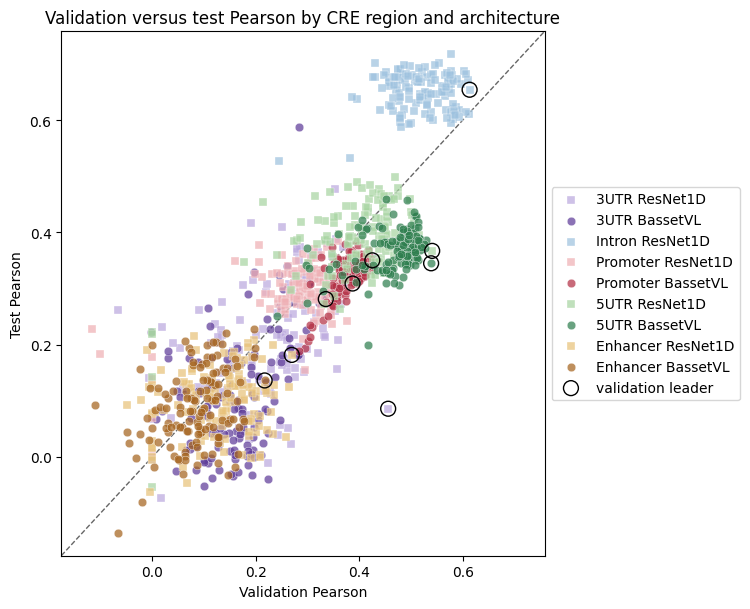

In [40]:
REGION_ARCH_COLORS = {
    # Within each region: lighter shade = ResNet1D, darker shade = BassetVL.
    ("Promoter", "ResNet1D"): "#efb0b5",
    ("Promoter", "BassetVL"): "#b33146",
    ("Intron", "ResNet1D"): "#9ec2df",
    ("Intron", "BassetVL"): "#2f5f8f",
    ("3UTR", "ResNet1D"): "#bba9de",
    ("3UTR", "BassetVL"): "#5e3c99",
    ("5UTR", "ResNet1D"): "#a8d5a2",
    ("5UTR", "BassetVL"): "#2f7f4f",
    ("Enhancer", "ResNet1D"): "#e8c27a",
    ("Enhancer", "BassetVL"): "#a5641f",
}
REGION_RC_COLORS = {
    ("Promoter", False): "#efb0b5",
    ("Promoter", True): "#b33146",
    ("Intron", False): "#9ec2df",
    ("Intron", True): "#2f5f8f",
    ("3UTR", False): "#bba9de",
    ("3UTR", True): "#5e3c99",
    ("5UTR", False): "#a8d5a2",
    ("5UTR", True): "#2f7f4f",
    ("Enhancer", False): "#e8c27a",
    ("Enhancer", True): "#a5641f",
}
ARCH_MARKERS = {"ResNet1D": "s", "BassetVL": "o"}


def rc_label(value):
    if pd.isna(value):
        return "RC unknown"
    return "RC on" if bool(value) else "RC off"


def plot_val_vs_test_hpo(
    df,
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    color_by="region_arch",
    title=None,
    ax=None,
):
    plot_df = df.copy()
    if regions is not None:
        plot_df = plot_df[plot_df["cre_region"].isin(regions)]
    if include_scopes is not None:
        plot_df = plot_df[plot_df["selection_scope"].isin(include_scopes)]
    plot_df = plot_df[
        plot_df["status"].eq("completed")
        & plot_df["health"].eq("ok")
        & plot_df["val_pearson"].notna()
        & plot_df["test_pearson"].notna()
    ].copy()
    if color_by == "region_rc":
        if "use_reverse_complements" not in plot_df.columns:
            raise ValueError("color_by='region_rc' requires a use_reverse_complements column")
        plot_df["rc_state"] = plot_df["use_reverse_complements"].map(normalize_bool)
        group_cols = ["cre_region", "architecture", "rc_state"]
    elif color_by == "region_arch":
        group_cols = ["cre_region", "architecture"]
    else:
        raise ValueError("color_by must be 'region_arch' or 'region_rc'")

    if ax is None:
        fig, ax = plt.subplots(figsize=(7.6, 6.2))
    else:
        fig = ax.figure

    for group_key, part in plot_df.groupby(group_cols, dropna=False, sort=False):
        if color_by == "region_rc":
            region, arch, rc_state = group_key
            color = REGION_RC_COLORS.get((region, rc_state), "0.45")
            label = f"{region} {arch}, {rc_label(rc_state)}"
        else:
            region, arch = group_key
            color = REGION_ARCH_COLORS.get((region, arch), "0.45")
            label = f"{region} {arch}"
        marker = ARCH_MARKERS.get(arch, "o")
        ax.scatter(
            part["val_pearson"], part["test_pearson"],
            label=label, color=color, marker=marker, alpha=0.72, s=38,
            edgecolors="white", linewidths=0.35,
        )

    leader_keys = ["cre_region", "architecture"] if color_by == "region_arch" else ["cre_region", "architecture", "rc_state"]
    leaders = plot_df.sort_values("val_pearson", ascending=False).groupby(leader_keys, dropna=False).head(1)
    ax.scatter(
        leaders["val_pearson"], leaders["test_pearson"],
        s=115, facecolors="none", edgecolors="black", linewidths=1.0, label="validation leader",
    )

    metrics = plot_df[["val_pearson", "test_pearson"]].to_numpy(dtype=float)
    lo = min(0, np.nanmin(metrics) - 0.04)
    hi = np.nanmax(metrics) + 0.04
    ax.plot([lo, hi], [lo, hi], color="0.4", linestyle="--", linewidth=1, zorder=0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Validation Pearson")
    ax.set_ylabel("Test Pearson")
    ax.set_title(title or "Validation versus test Pearson by scratch-HPO family")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
    return fig, ax


fig, ax = plot_val_vs_test_hpo(
    selection_subset,
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    color_by="region_arch",
    title="Validation versus test Pearson by CRE region and architecture",
)
fig.tight_layout()


## Bar And Violin Comparisons

The scatter plots above are useful for validation/test coupling, but bar and violin plots are easier when the question is architecture choice within each completed orchestrator part. By default these views follow the training-selection rule: choose the run with best validation Pearson, then show where that run lands on test Pearson. The max-test run remains visible as a diagnostic, not as the selected model. Within each region, lighter shade means ResNet1D and darker shade means BassetVL; the legend uses light/dark grey swatches so the shade rule is not tied to any one region color.


,cre_region,architecture,n_runs,selected_run_id,selected_val_pearson,selected_test_pearson,test_pearson_rank_desc,test_pearson_percentile,max_outcome_run_id,max_test_pearson,test_pearson_gap_to_max
0,3UTR,BassetVL,128,utc3cqzn,0.335262,0.281119,10,92.968750,pn50zxhm,0.586879,0.305760
1,3UTR,ResNet1D,127,8xcp9her,0.455851,0.085764,114,11.023622,39glhfll,0.477185,0.391421
2,5UTR,BassetVL,128,n9lzq306,0.538877,0.344869,92,28.906250,a5zoy95n,0.458869,0.114000
3,5UTR,ResNet1D,128,4a2z7obx,0.540936,0.367017,85,34.375000,yydnds86,0.498117,0.131099
4,Enhancer,BassetVL,127,rbdf02tt,0.217002,0.136143,31,76.377953,f0e9s0ef,0.227071,0.090928
5,Enhancer,ResNet1D,128,xugbiwmk,0.269468,0.181664,10,92.968750,6bfdqog1,0.215067,0.033403
6,Intron,ResNet1D,126,glgcweci,0.613275,0.654137,63,50.793651,qwnji00w,0.718182,0.064044
7,Promoter,BassetVL,128,cqg85h6j,0.425197,0.350152,26,80.468750,n0ersfw2,0.391424,0.041272
8,Promoter,ResNet1D,126,ilde84kd,0.387018,0.308844,49,61.904762,4oycxxgu,0.385108,0.076264


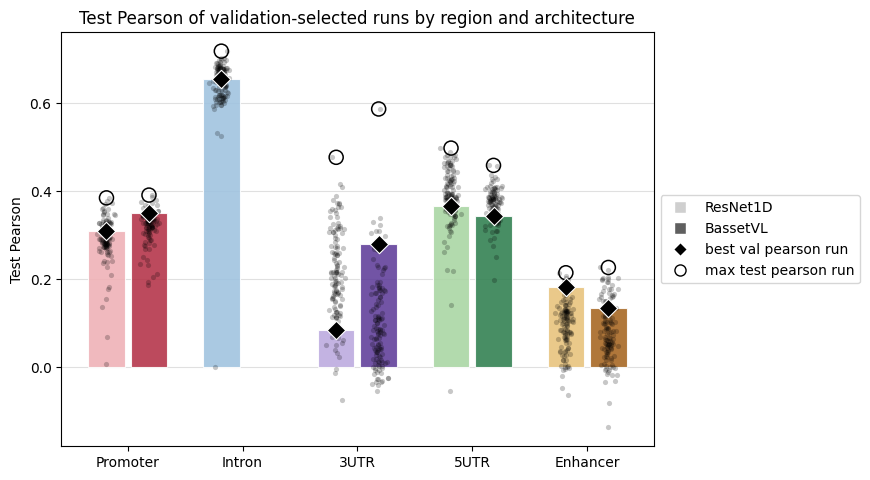

In [41]:
SHADE_LEGEND_COLORS = {
    "light": "#cfcfcf",
    "dark": "#5f5f5f",
}


def prepare_hpo_plot_df(
    df,
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    architectures=None,
    rc=None,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    metric="test_pearson",
    extra_metrics=("val_pearson",),
):
    plot_df = df.copy()
    if regions is not None:
        plot_df = plot_df[plot_df["cre_region"].isin(regions)]
    if architectures is not None:
        architectures = [architectures] if isinstance(architectures, str) else list(architectures)
        plot_df = plot_df[plot_df["architecture"].isin(architectures)]
    if include_scopes is not None:
        plot_df = plot_df[plot_df["selection_scope"].isin(include_scopes)]

    required = [metric, *extra_metrics]
    required = list(dict.fromkeys(col for col in required if col in plot_df.columns))
    metric_mask = True
    for col in required:
        metric_mask = metric_mask & plot_df[col].notna()
    plot_df = plot_df[
        plot_df["status"].eq("completed")
        & plot_df["health"].eq("ok")
        & metric_mask
    ].copy()

    if "use_reverse_complements" in plot_df.columns:
        plot_df["rc_state"] = plot_df["use_reverse_complements"].map(normalize_bool)
    else:
        plot_df["rc_state"] = np.nan

    if rc is not None:
        rc_values = [rc] if isinstance(rc, (bool, np.bool_)) else list(rc)
        rc_values = [normalize_bool(value) for value in rc_values]
        plot_df = plot_df[plot_df["rc_state"].isin(rc_values)]

    return plot_df


def ordered_unique(values, order=None):
    values = pd.Series(values).dropna().drop_duplicates().tolist()
    if order is None:
        return values
    return sorted(values, key=lambda value: order.get(value, 99))


def summarize_metric(values, summary):
    if summary == "max":
        return float(np.nanmax(values))
    if summary == "median":
        return float(np.nanmedian(values))
    if summary == "mean":
        return float(np.nanmean(values))
    raise ValueError("summary must be 'max', 'median', 'mean', or 'val_selected'")


def comparison_spec(comparison):
    if comparison in {"architecture", "region_architecture", "region_arch"}:
        return {
            "x_col": "cre_region",
            "hue_col": "architecture",
            "x_order": region_order,
            "hue_order": architecture_order,
            "color_fn": lambda region, hue: REGION_ARCH_COLORS.get((region, hue), "0.45"),
            "hue_label_fn": str,
            "legend_color_fn": lambda hue: SHADE_LEGEND_COLORS["light"] if hue == "ResNet1D" else SHADE_LEGEND_COLORS["dark"],
            "title_part": "architecture",
        }
    if comparison in {"rc", "region_rc"}:
        return {
            "x_col": "cre_region",
            "hue_col": "rc_state",
            "x_order": region_order,
            "hue_order": {False: 0, True: 1},
            "color_fn": lambda region, hue: REGION_RC_COLORS.get((region, hue), "0.45"),
            "hue_label_fn": rc_label,
            "legend_color_fn": lambda hue: SHADE_LEGEND_COLORS["dark"] if bool(hue) else SHADE_LEGEND_COLORS["light"],
            "title_part": "RC state",
        }
    raise ValueError("comparison must be 'architecture' or 'rc'")


def combo_selected_row(part, selection_metric):
    if selection_metric not in part.columns:
        raise ValueError(f"selection_metric {selection_metric!r} is not in the dataframe")
    return part.loc[part[selection_metric].idxmax()]


def combo_max_metric_row(part, metric):
    return part.loc[part[metric].idxmax()]


def compact_highlight_label(row, label_field="run_name", max_chars=24):
    value = row.get(label_field)
    if pd.isna(value) or value is None or str(value).strip() == "":
        value = row.get("run_id", "")
    value = str(value)
    if label_field == "run_name":
        for token in ["_scratch_", "_factorial_", "_fp32_", "_modal80_", "_modal100_"]:
            if token in value:
                value = value.split(token)[-1]
                break
    if len(value) > max_chars:
        value = "..." + value[-max_chars:]
    return value


def plot_hpo_combo_metric(
    df,
    comparison="architecture",
    kind="bar",
    metric="test_pearson",
    summary="val_selected",
    selection_metric="val_pearson",
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    architectures=None,
    rc=None,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    show_points=True,
    show_selected_marker=True,
    show_max_marker=True,
    label_highlights=False,
    label_field="run_name",
    label_max_chars=24,
    title=None,
    ax=None,
):
    spec = comparison_spec(comparison)
    plot_df = prepare_hpo_plot_df(
        df,
        regions=regions,
        architectures=architectures,
        rc=rc,
        include_scopes=include_scopes,
        metric=metric,
        extra_metrics=(selection_metric,),
    )
    plot_df = plot_df.dropna(subset=[spec["hue_col"]])
    if plot_df.empty:
        raise ValueError("No runs left after filtering")

    x_levels = ordered_unique(plot_df[spec["x_col"]], spec["x_order"])
    hue_levels = ordered_unique(plot_df[spec["hue_col"]], spec["hue_order"])

    if ax is None:
        width = max(7.2, 1.5 * len(x_levels) + 1.3)
        fig, ax = plt.subplots(figsize=(width, 4.9))
    else:
        fig = ax.figure

    n_hues = max(1, len(hue_levels))
    group_width = 0.74
    bar_width = group_width / n_hues
    x_base = np.arange(len(x_levels))
    rng = np.random.default_rng(7)

    for hue_idx, hue in enumerate(hue_levels):
        offset = (hue_idx - (n_hues - 1) / 2) * bar_width
        positions = x_base + offset
        values_for_violin = []
        positions_for_violin = []
        colors_for_violin = []

        for x_idx, x_level in enumerate(x_levels):
            part = plot_df[(plot_df[spec["x_col"]].eq(x_level)) & (plot_df[spec["hue_col"]].eq(hue))]
            color = spec["color_fn"](x_level, hue)
            if part.empty:
                continue

            vals = part[metric].to_numpy(dtype=float)
            selected = combo_selected_row(part, selection_metric)
            max_metric = combo_max_metric_row(part, metric)
            if summary == "val_selected":
                height = float(selected[metric])
            else:
                height = summarize_metric(vals, summary)

            if kind == "violin":
                values_for_violin.append(vals)
                positions_for_violin.append(positions[x_idx])
                colors_for_violin.append(color)
            elif kind == "bar":
                ax.bar(
                    positions[x_idx], height, width=bar_width * 0.86,
                    color=color, alpha=0.88, edgecolor="white", linewidth=0.8,
                )
            else:
                raise ValueError("kind must be 'bar' or 'violin'")

            if show_points:
                jitter = rng.normal(0, bar_width * 0.09, size=len(vals))
                ax.scatter(
                    np.full(len(vals), positions[x_idx]) + jitter,
                    vals,
                    s=14, color="black", alpha=0.22, linewidths=0, zorder=3,
                )
            if show_selected_marker:
                ax.scatter(
                    positions[x_idx], selected[metric],
                    s=88, marker="D", color="black", edgecolors="white", linewidths=0.8, zorder=5,
                )
                if label_highlights:
                    ax.annotate(
                        compact_highlight_label(selected, label_field=label_field, max_chars=label_max_chars),
                        xy=(positions[x_idx], selected[metric]),
                        xytext=(-6, 9), textcoords="offset points",
                        ha="right", va="bottom", fontsize=7, rotation=82,
                    )
            if show_max_marker:
                ax.scatter(
                    positions[x_idx], max_metric[metric],
                    s=102, marker="o", facecolors="none", edgecolors="black", linewidths=1.1, zorder=4,
                )
                if label_highlights and max_metric["run_id"] != selected["run_id"]:
                    ax.annotate(
                        compact_highlight_label(max_metric, label_field=label_field, max_chars=label_max_chars),
                        xy=(positions[x_idx], max_metric[metric]),
                        xytext=(6, 9), textcoords="offset points",
                        ha="left", va="bottom", fontsize=7, rotation=82,
                    )

        if kind == "violin" and values_for_violin:
            viol = ax.violinplot(
                values_for_violin,
                positions=positions_for_violin,
                widths=bar_width * 0.82,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body, color in zip(viol["bodies"], colors_for_violin):
                body.set_facecolor(color)
                body.set_edgecolor("white")
                body.set_alpha(0.78)
            viol["cmedians"].set_color("black")
            viol["cmedians"].set_linewidth(1.2)

    handles = []
    labels = []
    for hue in hue_levels:
        handles.append(plt.Line2D(
            [0], [0], marker="s", linestyle="", color="none",
            markerfacecolor=spec["legend_color_fn"](hue), markeredgecolor="white", markersize=9,
        ))
        labels.append(spec["hue_label_fn"](hue))
    if show_selected_marker:
        handles.append(plt.Line2D([0], [0], marker="D", linestyle="", color="black", markeredgecolor="white", markersize=7))
        labels.append(f"best {selection_metric.replace('_', ' ')} run")
    if show_max_marker:
        handles.append(plt.Line2D([0], [0], marker="o", linestyle="", color="black", markerfacecolor="none", markersize=8))
        labels.append(f"max {metric.replace('_', ' ')} run")

    ax.set_xticks(x_base)
    ax.set_xticklabels(x_levels)
    ax.set_ylabel(metric.replace("_", " ").title())
    if summary == "val_selected":
        summary_text = f"{metric.replace('_', ' ')} of best {selection_metric.replace('_', ' ')} run"
    else:
        summary_text = summary if kind == "bar" else "distribution"
    ax.set_title(title or f"{summary_text.title()} by {spec['title_part']}")
    ax.grid(axis="y", color="0.88", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
    return fig, ax, plot_df


def prepare_grouped_combo_df(
    df,
    metric="test_pearson",
    selection_metric="val_pearson",
    group_by=("cre_region", "architecture"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    architectures=None,
    rc=None,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
):
    plot_df = prepare_hpo_plot_df(
        df,
        regions=regions,
        architectures=architectures,
        rc=rc,
        include_scopes=include_scopes,
        metric=metric,
        extra_metrics=(selection_metric,),
    )
    if "use_reverse_complements" in group_by:
        plot_df["use_reverse_complements"] = plot_df["rc_state"]
    return plot_df


def max_metric_runs(
    df,
    metric="test_pearson",
    group_by=("cre_region", "architecture"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    architectures=None,
    rc=None,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    n=1,
):
    plot_df = prepare_grouped_combo_df(
        df,
        metric=metric,
        selection_metric="val_pearson",
        group_by=group_by,
        regions=regions,
        architectures=architectures,
        rc=rc,
        include_scopes=include_scopes,
    )
    top = plot_df.sort_values(metric, ascending=False).groupby(list(group_by), dropna=False).head(n)
    cols = [
        *group_by, "run_family", "run_id", "run_name", metric,
        "val_pearson", "test_pearson", "use_reverse_complements", "split_seed", "model_seed", "lr", "weight_decay",
    ]
    cols = list(dict.fromkeys(col for col in cols if col in top.columns))
    return top[cols].sort_values(list(group_by) + [metric], ascending=[True] * len(group_by) + [False])


def validation_selected_outcome_rank(
    df,
    selection_metric="val_pearson",
    outcome_metric="test_pearson",
    group_by=("cre_region", "architecture"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    architectures=None,
    rc=None,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
):
    plot_df = prepare_grouped_combo_df(
        df,
        metric=outcome_metric,
        selection_metric=selection_metric,
        group_by=group_by,
        regions=regions,
        architectures=architectures,
        rc=rc,
        include_scopes=include_scopes,
    )
    rows = []
    for group_key, part in plot_df.groupby(list(group_by), dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        selected = combo_selected_row(part, selection_metric)
        max_outcome = combo_max_metric_row(part, outcome_metric)
        selected_outcome = selected[outcome_metric]
        n_runs = len(part)
        rows.append({
            **dict(zip(group_by, group_key)),
            "n_runs": n_runs,
            "selected_run_id": selected["run_id"],
            f"selected_{selection_metric}": selected[selection_metric],
            f"selected_{outcome_metric}": selected_outcome,
            f"{outcome_metric}_rank_desc": int(part[outcome_metric].gt(selected_outcome).sum() + 1),
            f"{outcome_metric}_percentile": 100 * float(part[outcome_metric].le(selected_outcome).mean()),
            "max_outcome_run_id": max_outcome["run_id"],
            f"max_{outcome_metric}": max_outcome[outcome_metric],
            f"{outcome_metric}_gap_to_max": max_outcome[outcome_metric] - selected_outcome,
        })
    result = pd.DataFrame(rows)
    sort_cols = [col for col in ["cre_region", "architecture", "use_reverse_complements"] if col in result.columns]
    if sort_cols:
        result = result.sort_values(sort_cols)
    return result


def hparam_performance_contrast(
    df,
    metric="val_pearson",
    group_by=("cre_region", "architecture"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    architectures=None,
    rc=None,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    quantile=0.20,
    hparam_cols=None,
):
    if hparam_cols is None:
        hparam_cols = [
            "use_reverse_complements", "lr", "weight_decay", "linear_dropout_p", "dropout_p",
            "use_batch_norm", "batch_size", "scheduler", "stem_channels", "stem_kernel_size",
            "block_kernel_size", "head_hidden_channels", "conv1_channels", "conv1_kernel_size",
            "conv2_channels", "conv2_kernel_size", "conv3_channels", "conv3_kernel_size",
            "adaptive_pool_output_size", "n_linear_layers", "linear_channels", "linear_activation",
        ]
    plot_df = prepare_grouped_combo_df(
        df,
        metric=metric,
        selection_metric=metric,
        group_by=group_by,
        regions=regions,
        architectures=architectures,
        rc=rc,
        include_scopes=include_scopes,
    )
    rows = []
    for group_key, part in plot_df.groupby(list(group_by), dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        part = part.sort_values(metric)
        n = max(1, int(math.ceil(len(part) * quantile)))
        bottom = part.head(n)
        top = part.tail(n)
        for col in hparam_cols:
            if col not in part.columns or part[col].notna().sum() == 0:
                continue
            top_vals = top[col].dropna()
            bottom_vals = bottom[col].dropna()
            if top_vals.empty or bottom_vals.empty:
                continue
            row = {
                **dict(zip(group_by, group_key)),
                "hparam": col,
                "top_n": len(top),
                "bottom_n": len(bottom),
                f"top_{metric}_median": top[metric].median(),
                f"bottom_{metric}_median": bottom[metric].median(),
            }
            if pd.api.types.is_numeric_dtype(part[col]) and not pd.api.types.is_bool_dtype(part[col]):
                row.update({
                    "top_value": top_vals.median(),
                    "bottom_value": bottom_vals.median(),
                    "delta_top_minus_bottom": top_vals.median() - bottom_vals.median(),
                })
            else:
                row.update({
                    "top_value": top_vals.mode().iloc[0] if not top_vals.mode().empty else top_vals.iloc[0],
                    "bottom_value": bottom_vals.mode().iloc[0] if not bottom_vals.mode().empty else bottom_vals.iloc[0],
                    "delta_top_minus_bottom": np.nan,
                })
                if set(top_vals.dropna().unique()).issubset({True, False}) and set(bottom_vals.dropna().unique()).issubset({True, False}):
                    row["top_true_rate"] = top_vals.astype(bool).mean()
                    row["bottom_true_rate"] = bottom_vals.astype(bool).mean()
                    row["delta_true_rate"] = row["top_true_rate"] - row["bottom_true_rate"]
            rows.append(row)
    result = pd.DataFrame(rows)
    if result.empty:
        return result
    sort_cols = [col for col in ["cre_region", "architecture", "use_reverse_complements", "hparam"] if col in result.columns]
    return result.sort_values(sort_cols)


fig, ax, _ = plot_hpo_combo_metric(
    run_cfg,
    comparison="architecture",
    kind="bar",
    metric="test_pearson",
    summary="val_selected",
    selection_metric="val_pearson",
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    title="Test Pearson of validation-selected runs by region and architecture",
)
fig.tight_layout()

display(validation_selected_outcome_rank(
    run_cfg,
    selection_metric="val_pearson",
    outcome_metric="test_pearson",
    group_by=("cre_region", "architecture"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
))


### Distribution, RC, And Hyperparameter Views

Use the same helper for distribution shape (`kind="violin"`) or to swap the comparison to RC. The filled diamond is the validation-selected run placed on the test-Pearson y-axis; the open circle is the max-test run. The RC view is descriptive because the broad HPO grids mix architecture, split seed, model seed, and RC settings differently across parts. Treat it as a screening view for follow-up, not as a causal RC estimate.


,cre_region,use_reverse_complements,n_runs,selected_run_id,selected_val_pearson,selected_test_pearson,test_pearson_rank_desc,test_pearson_percentile,max_outcome_run_id,max_test_pearson,test_pearson_gap_to_max
0,3UTR,False,255,8xcp9her,0.455851,0.085764,178,30.588235,pn50zxhm,0.586879,0.501115
1,5UTR,False,119,sj1fzyge,0.515443,0.394435,54,55.462185,yydnds86,0.498117,0.103681
2,5UTR,True,137,4a2z7obx,0.540936,0.367017,64,54.014599,s72ys5nn,0.433253,0.066236
3,Enhancer,False,127,jp037quh,0.258330,0.034993,104,18.897638,6bfdqog1,0.215067,0.180074
4,Enhancer,True,128,xugbiwmk,0.269468,0.181664,11,92.187500,f0e9s0ef,0.227071,0.045406
5,Intron,False,57,n1lgjs2h,0.612131,0.610603,45,22.807018,qwnji00w,0.718182,0.107579
6,Intron,True,69,glgcweci,0.613275,0.654137,40,43.478261,dzhn934e,0.701777,0.047639
7,Promoter,False,167,cqg85h6j,0.425197,0.350152,25,85.628743,n0ersfw2,0.391424,0.041272
8,Promoter,True,87,ilde84kd,0.387018,0.308844,50,43.678161,4oycxxgu,0.385108,0.076264


,cre_region,architecture,use_reverse_complements,n_runs,selected_run_id,selected_val_pearson,selected_test_pearson,test_pearson_rank_desc,test_pearson_percentile,max_outcome_run_id,max_test_pearson,test_pearson_gap_to_max
0,3UTR,BassetVL,False,128,utc3cqzn,0.335262,0.281119,10,92.96875,pn50zxhm,0.586879,0.30576


,cre_region,architecture,use_reverse_complements,run_family,run_id,run_name,test_pearson,val_pearson,split_seed,model_seed,lr,weight_decay
346,3UTR,BassetVL,False,standardized scratch,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,0.586879,0.282984,303,NaN,0.001259,0.000223


,cre_region,architecture,hparam,top_n,bottom_n,top_val_pearson_median,bottom_val_pearson_median,top_value,bottom_value,delta_top_minus_bottom,top_true_rate,bottom_true_rate,delta_true_rate
13,3UTR,BassetVL,adaptive_pool_output_size,26,26,0.261390,0.074152,5.0,10.0,-5.000000,NaN,NaN,NaN
5,3UTR,BassetVL,batch_size,26,26,0.261390,0.074152,128.0,128.0,0.000000,NaN,NaN,NaN
7,3UTR,BassetVL,conv1_channels,26,26,0.261390,0.074152,111.5,89.5,22.000000,NaN,NaN,NaN
8,3UTR,BassetVL,conv1_kernel_size,26,26,0.261390,0.074152,9.0,11.0,-2.000000,NaN,NaN,NaN
9,3UTR,BassetVL,conv2_channels,26,26,0.261390,0.074152,150.0,146.0,4.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,Promoter,ResNet1D,stem_channels,26,26,0.345936,0.222453,83.0,76.0,7.000000,NaN,NaN,NaN
119,Promoter,ResNet1D,stem_kernel_size,26,26,0.345936,0.222453,5.0,7.0,-2.000000,NaN,NaN,NaN
115,Promoter,ResNet1D,use_batch_norm,26,26,0.345936,0.222453,False,True,NaN,0.500000,0.538462,-0.038462
111,Promoter,ResNet1D,use_reverse_complements,26,26,0.345936,0.222453,True,True,NaN,0.538462,0.538462,0.000000


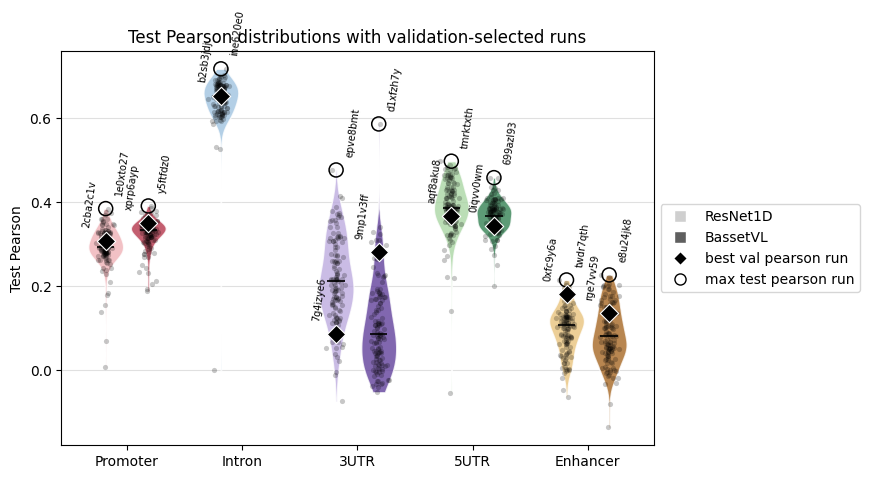

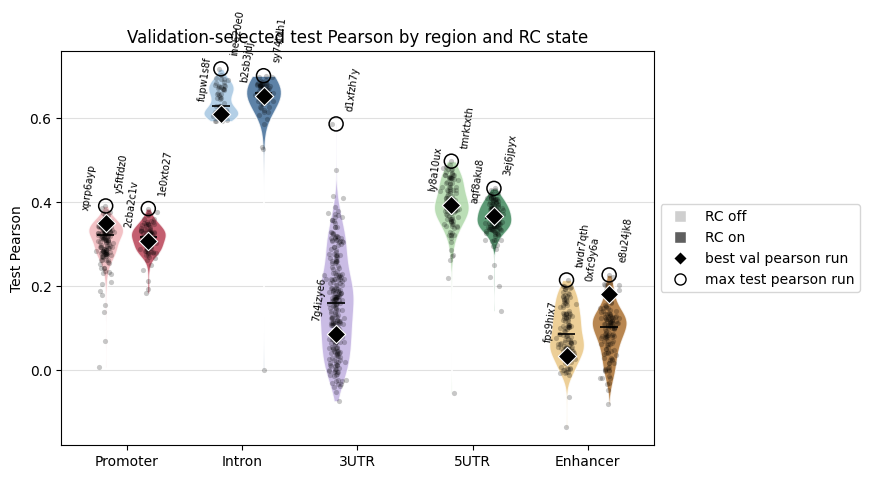

In [42]:
fig, ax, _ = plot_hpo_combo_metric(
    run_cfg,
    comparison="architecture",
    kind="violin",
    metric="test_pearson",
    summary="val_selected",
    selection_metric="val_pearson",
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    label_highlights=True,
    label_field="run_name",
    title="Test Pearson distributions with validation-selected runs",
)
fig.tight_layout()

fig, ax, _ = plot_hpo_combo_metric(
    run_cfg,
    comparison="rc",
    kind="violin",
    metric="test_pearson",
    summary="val_selected",
    selection_metric="val_pearson",
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    label_highlights=True,
    label_field="run_name",
    title="Validation-selected test Pearson by region and RC state",
)
fig.tight_layout()

display(validation_selected_outcome_rank(
    run_cfg,
    selection_metric="val_pearson",
    outcome_metric="test_pearson",
    group_by=("cre_region", "use_reverse_complements"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
))

# Example: isolate a specific question, such as 3UTR BassetVL RC/no-RC validation-selected and max-test runs.
display(validation_selected_outcome_rank(
    run_cfg,
    selection_metric="val_pearson",
    outcome_metric="test_pearson",
    group_by=("cre_region", "architecture", "use_reverse_complements"),
    regions=("3UTR",),
    architectures=("BassetVL",),
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
))

display(max_metric_runs(
    run_cfg,
    metric="test_pearson",
    group_by=("cre_region", "architecture", "use_reverse_complements"),
    regions=("3UTR",),
    architectures=("BassetVL",),
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
))

hparam_contrast = hparam_performance_contrast(
    run_cfg,
    metric="val_pearson",
    group_by=("cre_region", "architecture"),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    quantile=0.20,
)
display(hparam_contrast)


## Orchestrator Versus Earlier Same-Project HPO

These diagnostics compare completed full-orchestrator rows against earlier completed rows in the same W&B projects. The goal is not to select from earlier runs, but to check whether the full orchestrator landed in a wildly different performance regime. Large shifts in median or best validation/test Pearson would point to a setup difference, split difference, or search-space drift worth auditing before making biological conclusions.


,cre_region,architecture,source_cohort,n_runs,val_pearson_median,val_pearson_max,test_pearson_median,test_pearson_max
0,3UTR,BassetVL,Earlier same-project HPO,32,0.181263,0.378506,0.112793,0.419917
1,3UTR,BassetVL,Full orchestrator finished,128,0.162180,0.335262,0.086479,0.586879
2,3UTR,ResNet1D,Earlier same-project HPO,32,0.135230,0.280072,0.171072,0.340669
3,3UTR,ResNet1D,Full orchestrator finished,127,0.249745,0.455851,0.212951,0.477185
4,5UTR,BassetVL,Earlier same-project HPO,64,0.449804,0.531705,0.379111,0.457716
5,5UTR,BassetVL,Full orchestrator finished,128,0.484276,0.538877,0.368609,0.458869
6,5UTR,ResNet1D,Earlier same-project HPO,64,0.387808,0.482143,0.374570,0.486963
7,5UTR,ResNet1D,Full orchestrator finished,128,0.412329,0.540936,0.387699,0.498117
8,Enhancer,BassetVL,Earlier same-project HPO,2,0.083664,0.163564,0.096027,0.132240
9,Enhancer,BassetVL,Full orchestrator finished,127,0.091654,0.217002,0.081440,0.227071


,cre_region,architecture,n_runs__Earlier_same-project_HPO,n_runs__Full_orchestrator_finished,test_pearson_max__Earlier_same-project_HPO,test_pearson_max__Full_orchestrator_finished,test_pearson_median__Earlier_same-project_HPO,test_pearson_median__Full_orchestrator_finished,val_pearson_max__Earlier_same-project_HPO,val_pearson_max__Full_orchestrator_finished,val_pearson_median__Earlier_same-project_HPO,val_pearson_median__Full_orchestrator_finished,delta_orchestrator_minus_prior__val_pearson_median,delta_orchestrator_minus_prior__val_pearson_max,delta_orchestrator_minus_prior__test_pearson_median,delta_orchestrator_minus_prior__test_pearson_max
0,3UTR,BassetVL,32,128,0.419917,0.586879,0.112793,0.086479,0.378506,0.335262,0.181263,0.162180,-0.019083,-0.043244,-0.026314,0.166962
1,3UTR,ResNet1D,32,127,0.340669,0.477185,0.171072,0.212951,0.280072,0.455851,0.135230,0.249745,0.114514,0.175779,0.041879,0.136515
2,5UTR,BassetVL,64,128,0.457716,0.458869,0.379111,0.368609,0.531705,0.538877,0.449804,0.484276,0.034471,0.007172,-0.010502,0.001154
3,5UTR,ResNet1D,64,128,0.486963,0.498117,0.374570,0.387699,0.482143,0.540936,0.387808,0.412329,0.024521,0.058793,0.013128,0.011153
4,Enhancer,BassetVL,2,127,0.132240,0.227071,0.096027,0.081440,0.163564,0.217002,0.083664,0.091654,0.007990,0.053438,-0.014587,0.094831
5,Enhancer,ResNet1D,2,128,0.101813,0.215067,0.051992,0.108628,0.242599,0.269468,0.089902,0.142971,0.053069,0.026869,0.056636,0.113254
6,Intron,ResNet1D,32,126,0.718299,0.718182,0.659365,0.653627,0.602754,0.613275,0.544077,0.520745,-0.023332,0.010522,-0.005738,-0.000117
7,Promoter,BassetVL,48,128,0.366777,0.391424,0.323816,0.333654,0.406872,0.425197,0.362599,0.387696,0.025096,0.018325,0.009837,0.024647
8,Promoter,ResNet1D,34,126,0.393222,0.385108,0.319568,0.293684,0.365454,0.387018,0.295782,0.294964,-0.000818,0.021564,-0.025884,-0.008114


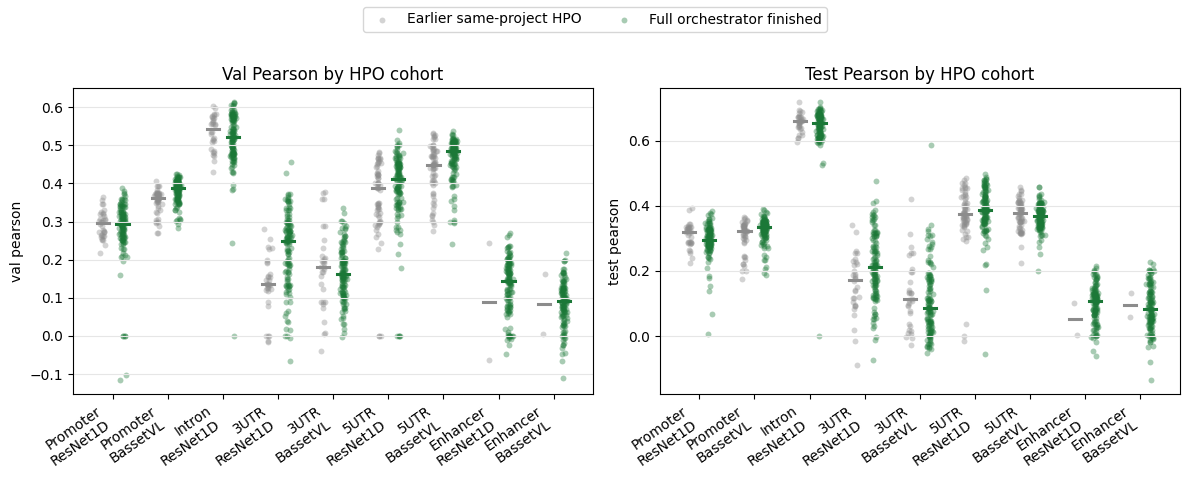

In [43]:
def prepare_orchestrator_vs_prior_df(
    df,
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    cohorts=("Earlier same-project HPO", "Full orchestrator finished"),
):
    plot_df = prepare_hpo_plot_df(
        df,
        regions=regions,
        include_scopes=COMPARISON_SCOPES,
        metric="test_pearson",
        extra_metrics=("val_pearson",),
    )
    plot_df = plot_df[plot_df["source_cohort"].isin(cohorts)].copy()
    plot_df["project_axis"] = plot_df["cre_region"] + "\n" + plot_df["architecture"]
    plot_df["region_order"] = plot_df["cre_region"].map(region_order).fillna(99)
    plot_df["architecture_order"] = plot_df["architecture"].map(architecture_order).fillna(99)
    return plot_df.sort_values(["region_order", "architecture_order", "source_cohort", "timestamp"])


def summarize_orchestrator_vs_prior(df):
    plot_df = prepare_orchestrator_vs_prior_df(df)
    summary = plot_df.groupby(["cre_region", "architecture", "source_cohort"], dropna=False).agg(
        n_runs=("run_id", "nunique"),
        val_pearson_median=("val_pearson", "median"),
        val_pearson_max=("val_pearson", "max"),
        test_pearson_median=("test_pearson", "median"),
        test_pearson_max=("test_pearson", "max"),
    ).reset_index()
    pivot = summary.pivot_table(
        index=["cre_region", "architecture"],
        columns="source_cohort",
        values=["n_runs", "val_pearson_median", "val_pearson_max", "test_pearson_median", "test_pearson_max"],
        aggfunc="first",
    )
    pivot.columns = ["__".join(col).replace(" ", "_") for col in pivot.columns.to_flat_index()]
    pivot = pivot.reset_index()
    for metric in ["val_pearson_median", "val_pearson_max", "test_pearson_median", "test_pearson_max"]:
        prior_col = f"{metric}__Earlier_same-project_HPO"
        orch_col = f"{metric}__Full_orchestrator_finished"
        if prior_col in pivot.columns and orch_col in pivot.columns:
            pivot[f"delta_orchestrator_minus_prior__{metric}"] = pivot[orch_col] - pivot[prior_col]
    return summary, pivot


def plot_orchestrator_vs_prior(df, metrics=("val_pearson", "test_pearson")):
    plot_df = prepare_orchestrator_vs_prior_df(df)
    if plot_df.empty:
        raise ValueError("No prior/full-orchestrator overlap found for comparison")
    x_levels = plot_df[["cre_region", "architecture", "project_axis"]].drop_duplicates()
    x_levels = x_levels.sort_values(
        by=["cre_region", "architecture"],
        key=lambda s: s.map({**region_order, **architecture_order}).fillna(99) if s.name in {"cre_region", "architecture"} else s,
    )
    labels = x_levels["project_axis"].tolist()
    x_lookup = {label: i for i, label in enumerate(labels)}
    cohort_offsets = {"Earlier same-project HPO": -0.18, "Full orchestrator finished": 0.18}
    cohort_colors = {"Earlier same-project HPO": "#8c8c8c", "Full orchestrator finished": "#1b7837"}
    rng = np.random.default_rng(17)

    fig, axes = plt.subplots(1, len(metrics), figsize=(6.0 * len(metrics), 4.8), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, metric in zip(axes, metrics):
        for cohort, part in plot_df.groupby("source_cohort", sort=False):
            xs = part["project_axis"].map(x_lookup).to_numpy(dtype=float) + cohort_offsets.get(cohort, 0)
            xs = xs + rng.normal(0, 0.025, size=len(xs))
            ax.scatter(
                xs, part[metric],
                s=18, alpha=0.38, color=cohort_colors.get(cohort, "0.45"),
                label=cohort, linewidths=0,
            )
            med = part.groupby("project_axis")[metric].median()
            for label, value in med.items():
                x = x_lookup[label] + cohort_offsets.get(cohort, 0)
                ax.plot([x - 0.11, x + 0.11], [value, value], color=cohort_colors.get(cohort, "0.45"), linewidth=2.2)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.set_ylabel(metric.replace("_", " "))
        ax.set_title(f"{metric.replace('_', ' ').title()} by HPO cohort")
        ax.grid(axis="y", color="0.9", linewidth=0.8)
    handles, labels_seen = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels_seen, handles))
    fig.legend(by_label.values(), by_label.keys(), loc="upper center", ncol=2, frameon=True)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig, axes, plot_df

cohort_summary, cohort_delta_summary = summarize_orchestrator_vs_prior(run_cfg)
display(cohort_summary)
display(cohort_delta_summary)
fig, axes, hpo_cohort_plot_df = plot_orchestrator_vs_prior(run_cfg)


## Split And Data Composition Diagnostics

These cells recreate the `BashorDataModule` split policy for each completed orchestrator part. Heldout rows are sampled only from high-barcode variants (`n_barcodes >= test_min_barcodes`) using `split_seed`; train then uses the remaining eligible rows (`n_barcodes >= train_min_barcodes`). This directly answers how many randomized validation/test split seeds were used, the train/validation/test proportions, base composition by split, and barcode-count versus RNA/DNA-target distributions per part.

Current split-seed coverage is uneven by design of the configs: promoter and intron use one split seed, 3'UTR uses four, and 5'UTR/enhancer use three. That is enough for a broad HPO screen, but additional split seeds would be valuable for final claims where the top models differ by only a few hundredths of Pearson R.


,part,n_split_seeds,split_seed_values,n_model_seeds,model_seed_values,val_frac_within_hq,test_frac_within_hq,val_size_within_hq,test_size_within_hq,test_min_barcodes,train_min_barcodes,train_size_frac,train_sampling_mode,config_paths
0,Promoter,1,[101],0,[],0.1295,0.1295,250.0,250.0,8,1,1.0,random,src/learn/configs/promoter/bashor_in_house/res...
1,Intron,1,[101],0,[],0.2000,0.2000,250.0,250.0,8,1,1.0,random,src/learn/configs/introns/bashor_in_house/resn...
2,3UTR,4,"[101, 202, 303, 404]",0,[],0.2500,0.2500,NaN,NaN,8,1,1.0,random,src/learn/configs/utr3/bashor_in_house/resnet1...
3,5UTR,3,"[101, 202, 303]",2,"[1701, 1702]",0.2000,0.2000,250.0,250.0,8,1,1.0,random,src/learn/configs/utr5/bashor_in_house/resnet1...
4,Enhancer,3,"[101, 202, 303]",2,"[1701, 1702]",0.2000,0.2000,250.0,250.0,8,1,1.0,random,src/learn/configs/enhancer/bashor_in_house/res...


,part,split_seed,split,n_rows,median_n_barcodes,mean_n_barcodes,median_rna_dna_target,mean_rna_dna_target,n_hq_total,n_leftover_hq_train,n_lower_quality_train,split_fraction_of_assigned
0,Promoter,101,train,7393,4.0,5.393751,1.869939,1.881783,1931,1431,5962,0.936653
1,Promoter,101,val,250,10.0,11.716000,1.816556,1.806114,1931,1431,5962,0.031674
2,Promoter,101,test,250,11.0,12.040000,1.836307,1.802815,1931,1431,5962,0.031674
3,Intron,101,train,7348,3.0,4.195972,2.201634,2.231801,1326,826,6522,0.936290
4,Intron,101,val,250,10.0,11.036000,2.102501,2.163953,1326,826,6522,0.031855
5,Intron,101,test,250,10.0,10.612000,2.147074,2.206622,1326,826,6522,0.031855
6,3UTR,101,train,6457,3.0,3.423726,2.058894,2.015426,775,387,6070,0.943316
7,3UTR,101,val,194,9.0,10.871134,1.967999,1.904066,775,387,6070,0.028342
8,3UTR,101,test,194,10.0,10.520619,2.024237,1.917949,775,387,6070,0.028342
9,3UTR,202,train,6457,3.0,3.429611,2.054862,2.011596,775,387,6070,0.943316


,part,split,n_rows_min,n_rows_median,n_rows_max,split_fraction_median,median_n_barcodes,median_rna_dna_target
0,Promoter,train,7393,7393.0,7393,0.936653,4.00,1.869939
1,Promoter,val,250,250.0,250,0.031674,10.00,1.816556
2,Promoter,test,250,250.0,250,0.031674,11.00,1.836307
3,Intron,train,7348,7348.0,7348,0.936290,3.00,2.201634
4,Intron,val,250,250.0,250,0.031855,10.00,2.102501
5,Intron,test,250,250.0,250,0.031855,10.00,2.147074
6,3UTR,train,6457,6457.0,6457,0.943316,3.00,2.057581
7,3UTR,val,194,194.0,194,0.028342,9.00,2.023954
8,3UTR,test,194,194.0,194,0.028342,9.75,2.030616
9,5UTR,train,7831,7831.0,7831,0.939983,4.00,2.581277


,part,split_seed,split,n_sequences,n_bases_acgt,frac_A,frac_C,frac_G,frac_T,gc_fraction
0,Promoter,101,train,7393,369481,0.187122,0.209288,0.317383,0.286207,0.526671
1,Promoter,101,val,250,12481,0.183799,0.209278,0.325294,0.281628,0.534573
2,Promoter,101,test,250,12498,0.184349,0.211154,0.319491,0.285006,0.530645
3,Intron,101,train,7348,587840,0.177490,0.219954,0.292159,0.310396,0.512114
4,Intron,101,val,250,20000,0.179700,0.213500,0.293850,0.312950,0.507350
5,Intron,101,test,250,20000,0.178700,0.221300,0.290950,0.309050,0.512250
6,3UTR,101,train,6457,645700,0.191719,0.208225,0.312109,0.287946,0.520335
7,3UTR,101,val,194,19400,0.192887,0.215155,0.311082,0.280876,0.526237
8,3UTR,101,test,194,19400,0.190412,0.208351,0.313041,0.288196,0.521392
9,3UTR,202,train,6457,645700,0.191796,0.208221,0.311820,0.288163,0.520040


,part,split,gc_fraction_min,gc_fraction_median,gc_fraction_max,gc_range_across_split_seeds
0,3UTR,test,0.521392,0.526933,0.534639,0.013247
1,3UTR,train,0.520040,0.520280,0.520339,0.000299
2,3UTR,val,0.521495,0.523067,0.526237,0.004742
3,5UTR,test,0.516560,0.523840,0.525200,0.008640
4,5UTR,train,0.526341,0.526479,0.526520,0.000179
5,5UTR,val,0.521920,0.527600,0.529280,0.007360
6,Enhancer,test,0.462836,0.463269,0.466706,0.003869
7,Enhancer,train,0.466073,0.466097,0.466116,0.000043
8,Enhancer,val,0.461208,0.465382,0.465415,0.004207
9,Intron,test,0.512250,0.512250,0.512250,0.000000


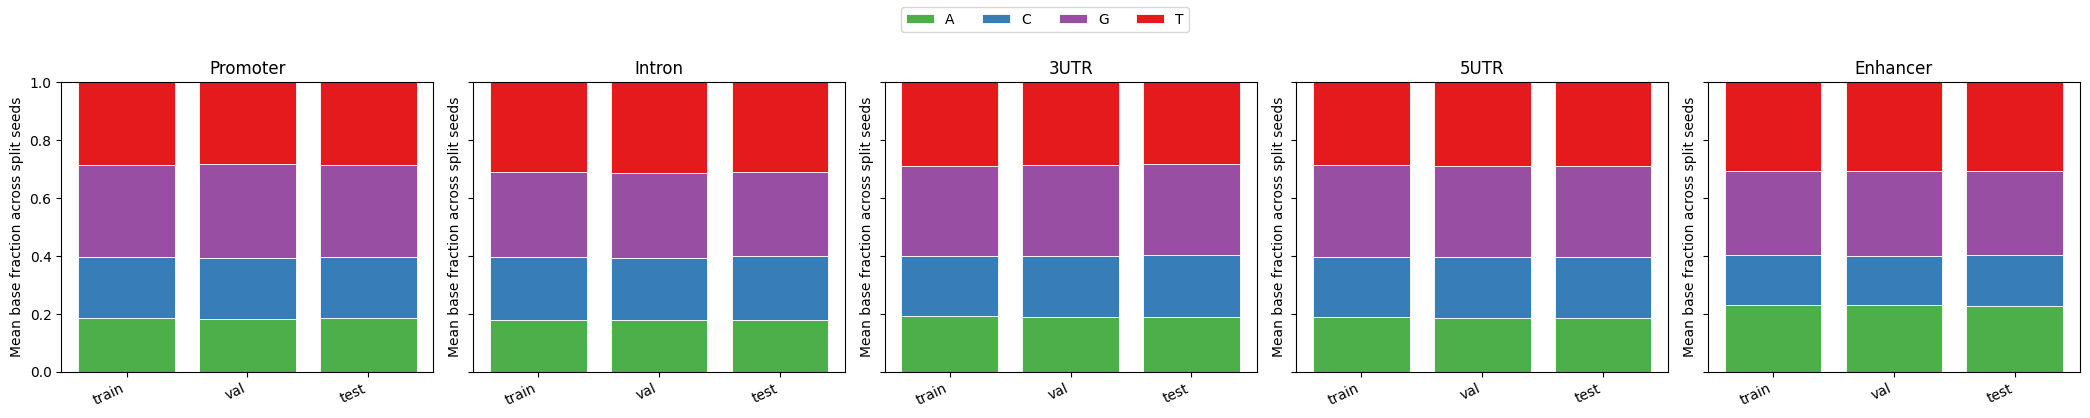

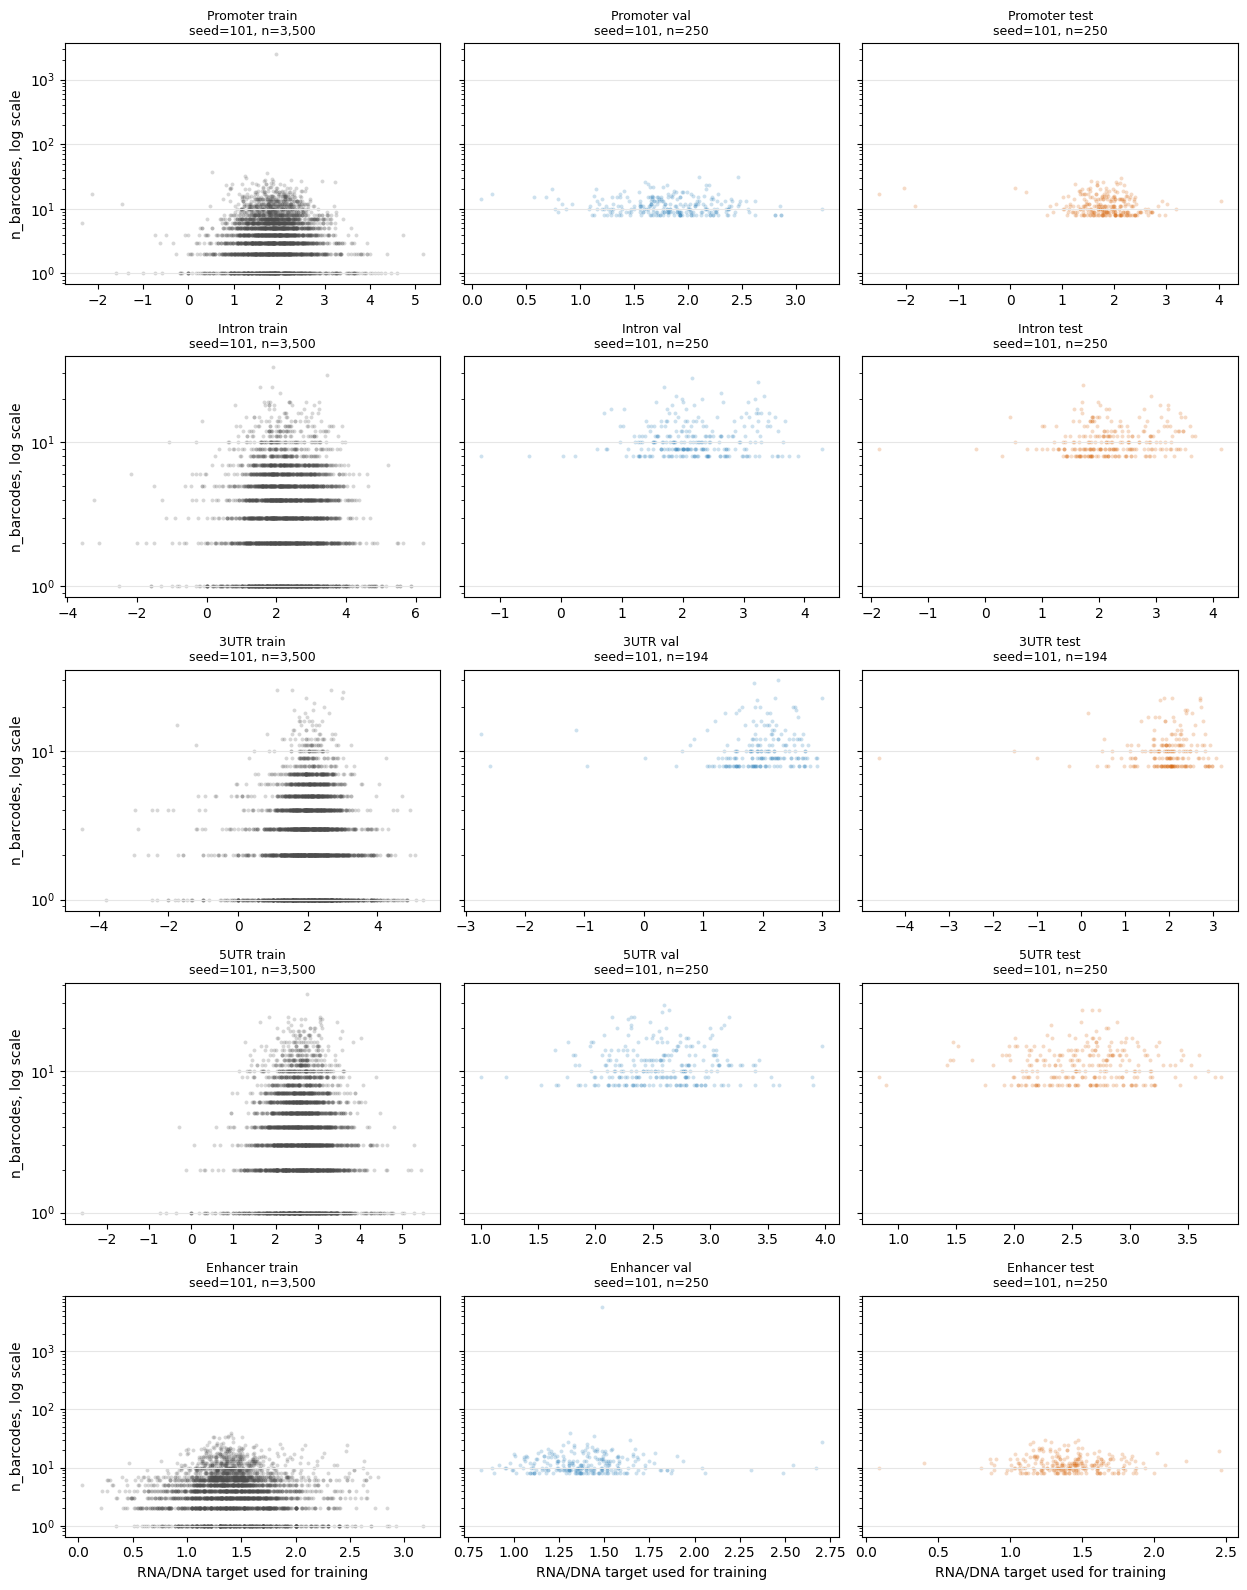

In [44]:
if yaml is None:
    raise ImportError("PyYAML is required for config-driven split diagnostics")

SPLIT_ORDER = ["train", "val", "test"]
BASE_ORDER = ["A", "C", "G", "T"]


def resolve_config_path(config_path):
    path = Path(str(config_path))
    if path.is_absolute():
        return path
    return LEARN / path


def read_sweep_config(config_path):
    path = resolve_config_path(config_path)
    with path.open() as fh:
        return yaml.safe_load(fh), path


def parameter_spec(config, key):
    return (config.get("parameters") or {}).get(key)


def parameter_values(config, key):
    spec = parameter_spec(config, key)
    if spec is None:
        return []
    if isinstance(spec, dict):
        if "values" in spec:
            return list(spec["values"])
        if "value" in spec:
            return [spec["value"]]
    return [spec]


def first_parameter_value(config, key, default=None):
    values = parameter_values(config, key)
    return values[0] if values else default


def unique_stable(values):
    out = []
    for value in values:
        if value not in out:
            out.append(value)
    return out


def params_for_orchestrator_part(part):
    rows = orchestrator_sweep_table[
        orchestrator_sweep_table["full_orchestrator_state"].eq("finished_included")
        & orchestrator_sweep_table["task_family"].eq(part)
    ].copy()
    if rows.empty:
        raise ValueError(f"No finished orchestrator configs found for {part}")
    configs = []
    config_paths = []
    for config_path in rows["config_path"].dropna().drop_duplicates():
        cfg, resolved = read_sweep_config(config_path)
        configs.append(cfg)
        config_paths.append(resolved)

    keys = [
        "datafile_path", "sep", "sequence_column", "target_column", "barcode_column",
        "test_min_barcodes", "train_min_barcodes", "val_frac_within_hq", "test_frac_within_hq",
        "val_size_within_hq", "test_size_within_hq", "train_size_frac", "train_sampling_mode",
        "split_seed", "model_seed",
    ]
    values_by_key = {}
    for key in keys:
        values = []
        for cfg in configs:
            values.extend(parameter_values(cfg, key))
        values_by_key[key] = unique_stable(values)

    fixed = {}
    for key in keys:
        vals = values_by_key[key]
        fixed[key] = vals[0] if vals else None
    fixed["split_seed_values"] = values_by_key["split_seed"] or [fixed.get("split_seed")]
    fixed["split_seed_values"] = [int(seed) for seed in fixed["split_seed_values"] if seed is not None]
    fixed["model_seed_values"] = [int(seed) for seed in values_by_key["model_seed"] if seed is not None]
    fixed["config_paths"] = [rel_to_root(path) for path in config_paths]
    fixed["part"] = part
    return fixed


FINISHED_PARTS = ["promoter", "introns", "utr3", "utr5", "enhancer"]
part_params = {part: params_for_orchestrator_part(part) for part in FINISHED_PARTS}


def display_part_name(part):
    return {"promoter": "Promoter", "intron": "Intron", "introns": "Intron", "utr3": "3UTR", "utr5": "5UTR", "enhancer": "Enhancer"}.get(part, part)


seed_policy_rows = []
for part, params in part_params.items():
    seed_policy_rows.append({
        "part": display_part_name(part),
        "n_split_seeds": len(params["split_seed_values"]),
        "split_seed_values": params["split_seed_values"],
        "n_model_seeds": len(params["model_seed_values"]),
        "model_seed_values": params["model_seed_values"],
        "val_frac_within_hq": params["val_frac_within_hq"],
        "test_frac_within_hq": params["test_frac_within_hq"],
        "val_size_within_hq": params["val_size_within_hq"],
        "test_size_within_hq": params["test_size_within_hq"],
        "test_min_barcodes": params["test_min_barcodes"],
        "train_min_barcodes": params["train_min_barcodes"],
        "train_size_frac": params["train_size_frac"],
        "train_sampling_mode": params["train_sampling_mode"],
        "config_paths": "; ".join(params["config_paths"]),
    })
seed_policy_summary = pd.DataFrame(seed_policy_rows)
display(seed_policy_summary)


def sep_value(value):
    return "\t" if value in {"tab", "\\t"} else value


def load_part_frame(params):
    path = Path(params["datafile_path"])
    if not path.is_absolute():
        path = LEARN / path
    df = pd.read_csv(path, sep=sep_value(params.get("sep", "\t")), low_memory=False).copy()
    target_col = params["target_column"]
    barcode_col = params["barcode_column"]
    seq_col = params["sequence_column"]
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df[barcode_col] = pd.to_numeric(df[barcode_col], errors="coerce")
    df = df.loc[
        df[seq_col].notna()
        & df[barcode_col].notna()
        & np.isfinite(df[target_col])
    ].reset_index(drop=True)
    df["row_id"] = np.arange(len(df))
    return df


def assign_lib1_splits(df, params, split_seed):
    seq_col = params["sequence_column"]
    target_col = params["target_column"]
    barcode_col = params["barcode_column"]
    test_min = int(params.get("test_min_barcodes") or 4)
    train_min = int(params.get("train_min_barcodes") or 1)
    val_frac = float(params.get("val_frac_within_hq") or 0.2)
    test_frac = float(params.get("test_frac_within_hq") or 0.2)
    val_size = params.get("val_size_within_hq")
    test_size = params.get("test_size_within_hq")
    train_size_frac = float(params.get("train_size_frac") or 1.0)
    train_sampling_mode = params.get("train_sampling_mode") or "hq_first"

    hq_df = df.loc[df[barcode_col] >= test_min].copy()
    rng = np.random.default_rng(int(split_seed))
    perm = rng.permutation(hq_df.index.to_numpy())
    n_hq = len(perm)
    n_test = int(test_size) if test_size is not None else max(1, int(round(n_hq * test_frac)))
    n_val = int(val_size) if val_size is not None else max(1, int(round(n_hq * val_frac)))
    if n_test + n_val >= n_hq:
        if test_size is not None or val_size is not None:
            raise ValueError(f"Requested val/test sizes ({n_val}/{n_test}) exhaust HQ rows ({n_hq})")
        n_test = max(1, n_hq // 5)
        n_val = max(1, n_hq // 5)

    test_idx = set(perm[:n_test].tolist())
    val_idx = set(perm[n_test:n_test + n_val].tolist())
    used_idx = test_idx | val_idx

    split_frames = []
    for split_name, idx in [("test", test_idx), ("val", val_idx)]:
        frame = df.loc[df.index.isin(idx), ["row_id", seq_col, target_col, barcode_col]].copy()
        frame["split"] = split_name
        split_frames.append(frame)

    rest = df.loc[~df.index.isin(used_idx)].copy().reset_index(drop=True)
    eligible = rest.loc[rest[barcode_col] >= train_min].copy().reset_index(drop=True)
    leftover_hq = eligible.loc[eligible[barcode_col] >= test_min].copy().reset_index(drop=True)
    lower_quality = eligible.loc[eligible[barcode_col] < test_min].copy().reset_index(drop=True)
    if train_size_frac >= 1.0:
        train = eligible.copy()
    else:
        train_n = min(len(eligible), max(32, int(round(len(eligible) * train_size_frac))))
        if train_sampling_mode == "random":
            train = eligible.sample(n=train_n, random_state=int(split_seed), replace=False).reset_index(drop=True)
        elif train_sampling_mode == "hq_first":
            hq_take = min(train_n, len(leftover_hq))
            lq_take = max(0, train_n - hq_take)
            pieces = []
            if hq_take:
                pieces.append(leftover_hq.sample(n=hq_take, random_state=int(split_seed), replace=False))
            if lq_take:
                pieces.append(lower_quality.sample(n=lq_take, random_state=int(split_seed) + 100003, replace=False))
            train = pd.concat(pieces, ignore_index=True).sample(frac=1.0, random_state=int(split_seed) + 7919).reset_index(drop=True)
        else:
            raise ValueError(f"Unknown train_sampling_mode: {train_sampling_mode}")
    train = train[["row_id", seq_col, target_col, barcode_col]].copy()
    train["split"] = "train"
    split_frames.append(train)

    assigned = pd.concat(split_frames, ignore_index=True)
    assigned = assigned.rename(columns={seq_col: "sequence", target_col: "rna_dna_target", barcode_col: "n_barcodes"})
    assigned["split_seed"] = int(split_seed)
    assigned["n_hq_total"] = int(n_hq)
    assigned["n_leftover_hq_train"] = int((train[barcode_col] >= test_min).sum())
    assigned["n_lower_quality_train"] = int((train[barcode_col] < test_min).sum())
    return assigned


split_frames = []
for part, params in part_params.items():
    frame = load_part_frame(params)
    for seed in params["split_seed_values"]:
        assigned = assign_lib1_splits(frame, params, seed)
        assigned["part"] = display_part_name(part)
        assigned["part_key"] = part
        split_frames.append(assigned)

split_assignments = pd.concat(split_frames, ignore_index=True)
split_assignments["split"] = pd.Categorical(split_assignments["split"], categories=SPLIT_ORDER, ordered=True)
split_assignments["part"] = pd.Categorical(split_assignments["part"], categories=list(FINISHED_ORCHESTRATOR_REGIONS), ordered=True)

split_size_summary = split_assignments.groupby(["part", "split_seed", "split"], observed=True).agg(
    n_rows=("row_id", "nunique"),
    median_n_barcodes=("n_barcodes", "median"),
    mean_n_barcodes=("n_barcodes", "mean"),
    median_rna_dna_target=("rna_dna_target", "median"),
    mean_rna_dna_target=("rna_dna_target", "mean"),
    n_hq_total=("n_hq_total", "first"),
    n_leftover_hq_train=("n_leftover_hq_train", "first"),
    n_lower_quality_train=("n_lower_quality_train", "first"),
).reset_index()
split_size_summary["split_fraction_of_assigned"] = split_size_summary["n_rows"] / split_size_summary.groupby(["part", "split_seed"], observed=True)["n_rows"].transform("sum")
display(split_size_summary)

split_size_rollup = split_size_summary.groupby(["part", "split"], observed=True).agg(
    n_rows_min=("n_rows", "min"),
    n_rows_median=("n_rows", "median"),
    n_rows_max=("n_rows", "max"),
    split_fraction_median=("split_fraction_of_assigned", "median"),
    median_n_barcodes=("median_n_barcodes", "median"),
    median_rna_dna_target=("median_rna_dna_target", "median"),
).reset_index()
display(split_size_rollup)


def base_fraction_table(assignments):
    rows = []
    for (part, seed, split), frame in assignments.groupby(["part", "split_seed", "split"], observed=True):
        seqs = frame["sequence"].dropna().astype(str).str.upper()
        joined = "".join(seqs.tolist())
        total = sum(joined.count(base) for base in BASE_ORDER)
        row = {"part": part, "split_seed": seed, "split": split, "n_sequences": len(seqs), "n_bases_acgt": total}
        for base in BASE_ORDER:
            row[f"frac_{base}"] = joined.count(base) / total if total else np.nan
        row["gc_fraction"] = row["frac_G"] + row["frac_C"]
        rows.append(row)
    return pd.DataFrame(rows)


base_summary = base_fraction_table(split_assignments)
display(base_summary)


def plot_base_composition_by_part(base_summary):
    mean_base = base_summary.groupby(["part", "split"], observed=True)[[f"frac_{b}" for b in BASE_ORDER]].mean().reset_index()
    parts = [part for part in FINISHED_ORCHESTRATOR_REGIONS if part in set(mean_base["part"].astype(str))]
    fig, axes = plt.subplots(1, len(parts), figsize=(4.2 * len(parts), 4.2), sharey=True)
    axes = np.atleast_1d(axes)
    base_colors = {"A": "#4daf4a", "C": "#377eb8", "G": "#984ea3", "T": "#e41a1c"}
    for ax, part in zip(axes, parts):
        part_df = mean_base[mean_base["part"].astype(str).eq(part)].set_index("split").reindex(SPLIT_ORDER)
        bottom = np.zeros(len(SPLIT_ORDER))
        x = np.arange(len(SPLIT_ORDER))
        for base in BASE_ORDER:
            vals = part_df[f"frac_{base}"].to_numpy(dtype=float)
            ax.bar(x, vals, bottom=bottom, color=base_colors[base], label=base, edgecolor="white", linewidth=0.6)
            bottom += np.nan_to_num(vals)
        ax.set_xticks(x)
        ax.set_xticklabels(SPLIT_ORDER, rotation=25, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(part)
        ax.set_ylabel("Mean base fraction across split seeds")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=True)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig, axes

fig, axes = plot_base_composition_by_part(base_summary)

base_drift_summary = base_summary.groupby(["part", "split"], observed=True).agg(
    gc_fraction_min=("gc_fraction", "min"),
    gc_fraction_median=("gc_fraction", "median"),
    gc_fraction_max=("gc_fraction", "max"),
).reset_index()
base_drift_summary["gc_range_across_split_seeds"] = base_drift_summary["gc_fraction_max"] - base_drift_summary["gc_fraction_min"]
display(base_drift_summary)


def representative_seed_by_part():
    return {display_part_name(part): min(params["split_seed_values"]) for part, params in part_params.items()}


def plot_barcode_vs_target_by_split(assignments, max_points_per_panel=3500):
    rep_seed = representative_seed_by_part()
    plot_df = assignments[assignments.apply(lambda row: int(row["split_seed"]) == rep_seed[str(row["part"])], axis=1)].copy()
    parts = [part for part in FINISHED_ORCHESTRATOR_REGIONS if part in set(plot_df["part"].astype(str))]
    fig, axes = plt.subplots(len(parts), len(SPLIT_ORDER), figsize=(4.2 * len(SPLIT_ORDER), 3.2 * len(parts)), squeeze=False, sharey="row")
    split_colors = {"train": "#4d4d4d", "val": "#1f77b4", "test": "#d55e00"}
    rng = np.random.default_rng(23)
    for row_idx, part in enumerate(parts):
        for col_idx, split in enumerate(SPLIT_ORDER):
            ax = axes[row_idx, col_idx]
            part_split = plot_df[plot_df["part"].astype(str).eq(part) & plot_df["split"].astype(str).eq(split)].copy()
            if len(part_split) > max_points_per_panel:
                part_split = part_split.sample(n=max_points_per_panel, random_state=17)
            x = part_split["rna_dna_target"].to_numpy(dtype=float)
            y = part_split["n_barcodes"].to_numpy(dtype=float)
            ax.scatter(x, y, s=8, alpha=0.22, color=split_colors[split], linewidths=0)
            ax.set_yscale("log")
            ax.grid(axis="y", color="0.9", linewidth=0.8)
            seed = rep_seed[part]
            ax.set_title(f"{part} {split}\nseed={seed}, n={len(part_split):,}", fontsize=9)
            if row_idx == len(parts) - 1:
                ax.set_xlabel("RNA/DNA target used for training")
            if col_idx == 0:
                ax.set_ylabel("n_barcodes, log scale")
    fig.tight_layout()
    return fig, axes, plot_df

fig, axes, representative_split_plot_df = plot_barcode_vs_target_by_split(split_assignments)


### Learning Curves For Highlighted Runs

The table below collects validation-selected and max-test diagnostic runs from the completed orchestrator slice. Curves use local W&B history TSVs exported from `src/learn/wandb` into `src/learn/run_registry/wandb_history_exports/lib1_three_region_selected` or sibling export folders. Each panel plots Pearson R versus epoch for train, validation, and test. The dashed vertical line marks the registry `best_epoch`/checkpoint epoch, and the dotted line marks the last logged epoch, which is the practical stop point for early-stopped runs.

A second focused grid below adds the 5'UTR and enhancer top performers from the full orchestrator sweeps. These histories are exported to `src/learn/run_registry/wandb_history_exports/lib1_utr5_enhancer_top_performers` so the plots are reproducible from local W&B cache files.

,inspection_view,combo_label,curve_role,run_id,run_name,cre_region,architecture,run_family,best_epoch,val_pearson,test_pearson,use_reverse_complements,split_seed,model_seed,lr,weight_decay,history_path,history_found
21,3UTR BassetVL RC,3UTR | BassetVL | RC off,max-test diagnostic,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,3UTR,BassetVL,standardized scratch,24,0.282984,0.586879,False,303,NaN,0.001259,0.000223,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
20,3UTR BassetVL RC,3UTR | BassetVL | RC off,validation-selected,utc3cqzn,threeprime_modal100_utr_bassetvl_fp32_9mp1v3ff,3UTR,BassetVL,standardized scratch,50,0.335262,0.281119,False,404,NaN,0.001863,0.000712,None,False
11,Region RC,3UTR | RC off,max-test diagnostic,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,3UTR,BassetVL,standardized scratch,24,0.282984,0.586879,False,303,NaN,0.001259,0.000223,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
10,Region RC,3UTR | RC off,validation-selected,8xcp9her,threeprime_modal100_resnet1d_fp32_7g4izye6,3UTR,ResNet1D,standardized scratch,80,0.455851,0.085764,False,101,NaN,0.000279,0.000015,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
13,Region RC,Intron | RC off,max-test diagnostic,qwnji00w,lib1_intron_modal80_resnet1d_scratch_ine620e0,Intron,ResNet1D,standardized scratch,23,0.578246,0.718182,False,101,NaN,0.000092,0.000136,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
12,Region RC,Intron | RC off,validation-selected,n1lgjs2h,lib1_intron_modal80_resnet1d_scratch_fupw1s8f,Intron,ResNet1D,standardized scratch,110,0.612131,0.610603,False,101,NaN,0.000071,0.000002,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
15,Region RC,Intron | RC on,max-test diagnostic,dzhn934e,lib1_intron_modal80_resnet1d_scratch_sy74tdh1,Intron,ResNet1D,standardized scratch,21,0.431192,0.701777,True,101,NaN,0.000127,0.000024,None,False
14,Region RC,Intron | RC on,validation-selected,glgcweci,lib1_intron_modal80_resnet1d_scratch_b2sb3jdj,Intron,ResNet1D,standardized scratch,78,0.613275,0.654137,True,101,NaN,0.000100,0.001772,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
17,Region RC,Promoter | RC off,max-test diagnostic,n0ersfw2,lib1_promoter_promoter_bassetvl_scratch_y5ftfdz0,Promoter,BassetVL,standardized scratch,24,0.381967,0.391424,False,101,NaN,0.000642,0.000152,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
16,Region RC,Promoter | RC off,validation-selected,cqg85h6j,lib1_promoter_promoter_bassetvl_scratch_xprp6ayp,Promoter,BassetVL,standardized scratch,73,0.425197,0.350152,False,101,NaN,0.000131,0.000478,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True


,run_id,run_name,cre_region,architecture,run_family,use_reverse_complements,best_epoch,val_pearson,test_pearson,curve_roles,inspection_views,combo_labels,history_found,history_path
9,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,3UTR,BassetVL,standardized scratch,False,24,0.282984,0.586879,max-test diagnostic,3UTR BassetVL RC; Region RC; Region architecture,3UTR | BassetVL; 3UTR | BassetVL | RC off; 3UT...,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
11,utc3cqzn,threeprime_modal100_utr_bassetvl_fp32_9mp1v3ff,3UTR,BassetVL,standardized scratch,False,50,0.335262,0.281119,validation-selected,3UTR BassetVL RC; Region architecture,3UTR | BassetVL; 3UTR | BassetVL | RC off,False,None
0,39glhfll,threeprime_modal100_resnet1d_fp32_epve8bmt,3UTR,ResNet1D,standardized scratch,False,83,0.353463,0.477185,max-test diagnostic,Region architecture,3UTR | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
2,8xcp9her,threeprime_modal100_resnet1d_fp32_7g4izye6,3UTR,ResNet1D,standardized scratch,False,80,0.455851,0.085764,validation-selected,Region RC; Region architecture,3UTR | RC off; 3UTR | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
4,dzhn934e,lib1_intron_modal80_resnet1d_scratch_sy74tdh1,Intron,ResNet1D,standardized scratch,True,21,0.431192,0.701777,max-test diagnostic,Region RC,Intron | RC on,False,None
10,qwnji00w,lib1_intron_modal80_resnet1d_scratch_ine620e0,Intron,ResNet1D,standardized scratch,False,23,0.578246,0.718182,max-test diagnostic,Region RC; Region architecture,Intron | RC off; Intron | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
5,glgcweci,lib1_intron_modal80_resnet1d_scratch_b2sb3jdj,Intron,ResNet1D,standardized scratch,True,78,0.613275,0.654137,validation-selected,Region RC; Region architecture,Intron | RC on; Intron | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
8,n1lgjs2h,lib1_intron_modal80_resnet1d_scratch_fupw1s8f,Intron,ResNet1D,standardized scratch,False,110,0.612131,0.610603,validation-selected,Region RC,Intron | RC off,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
7,n0ersfw2,lib1_promoter_promoter_bassetvl_scratch_y5ftfdz0,Promoter,BassetVL,standardized scratch,False,24,0.381967,0.391424,max-test diagnostic,Region RC; Region architecture,Promoter | BassetVL; Promoter | RC off,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
3,cqg85h6j,lib1_promoter_promoter_bassetvl_scratch_xprp6ayp,Promoter,BassetVL,standardized scratch,False,73,0.425197,0.350152,validation-selected,Region RC; Region architecture,Promoter | BassetVL; Promoter | RC off,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...


,run_id,run_name,cre_region,architecture,rc_state,best_epoch,history_found,history_path,n_train_epochs,n_val_epochs,n_test_epochs,test_logging
0,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,3UTR,BassetVL,RC off,24,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,71,70,71,per-epoch curve
1,utc3cqzn,threeprime_modal100_utr_bassetvl_fp32_9mp1v3ff,3UTR,BassetVL,RC off,50,False,None,0,0,0,not logged in history
2,39glhfll,threeprime_modal100_resnet1d_fp32_epve8bmt,3UTR,ResNet1D,RC off,83,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,115,114,115,per-epoch curve
3,8xcp9her,threeprime_modal100_resnet1d_fp32_7g4izye6,3UTR,ResNet1D,RC off,80,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,112,111,112,per-epoch curve
4,dzhn934e,lib1_intron_modal80_resnet1d_scratch_sy74tdh1,Intron,ResNet1D,RC on,21,False,None,0,0,0,not logged in history
6,glgcweci,lib1_intron_modal80_resnet1d_scratch_b2sb3jdj,Intron,ResNet1D,RC on,78,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,115,114,115,per-epoch curve
7,n1lgjs2h,lib1_intron_modal80_resnet1d_scratch_fupw1s8f,Intron,ResNet1D,RC off,110,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,147,146,147,per-epoch curve
5,qwnji00w,lib1_intron_modal80_resnet1d_scratch_ine620e0,Intron,ResNet1D,RC off,23,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,60,59,60,per-epoch curve
9,cqg85h6j,lib1_promoter_promoter_bassetvl_scratch_xprp6ayp,Promoter,BassetVL,RC off,73,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,105,104,105,per-epoch curve
8,n0ersfw2,lib1_promoter_promoter_bassetvl_scratch_y5ftfdz0,Promoter,BassetVL,RC off,24,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,56,55,56,per-epoch curve


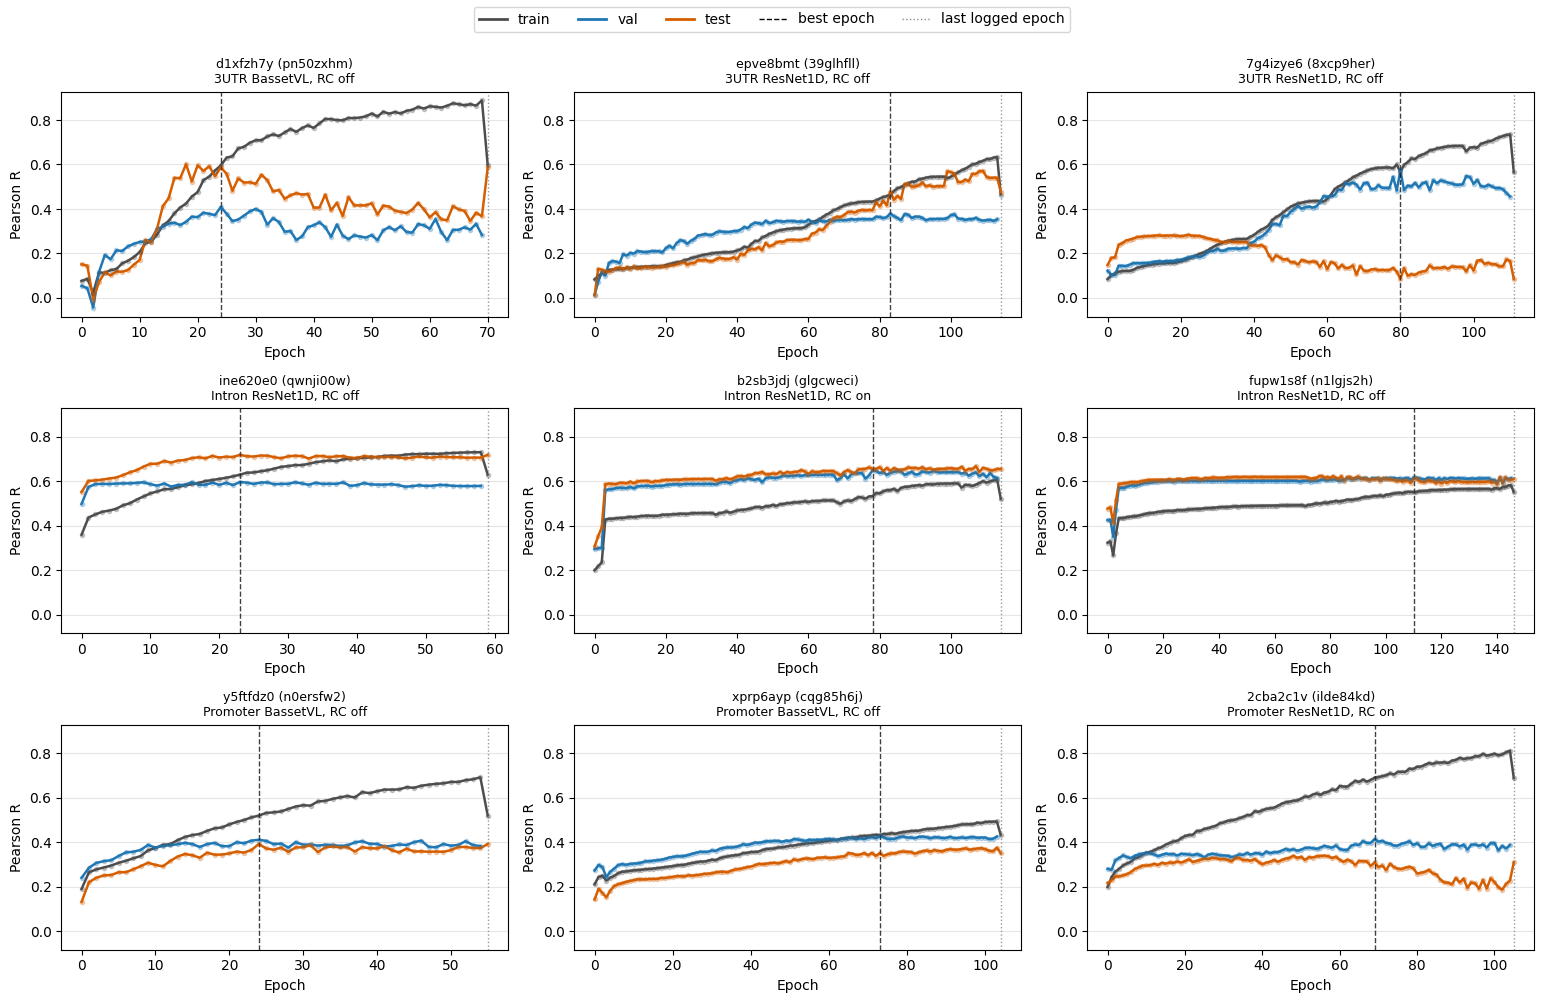

In [45]:
HISTORY_EXPORT_DIR = RUN_REGISTRY / "wandb_history_exports" / "lib1_three_region_selected"
HISTORY_SEARCH_DIRS = [HISTORY_EXPORT_DIR, RUN_REGISTRY / "wandb_history_exports"]


def history_path_for_run(run_id, search_dirs=HISTORY_SEARCH_DIRS):
    run_id = str(run_id)
    for directory in search_dirs:
        if not directory.exists():
            continue
        matches = sorted(directory.glob(f"**/*__{run_id}__history.tsv"))
        if matches:
            return matches[0]
        matches = sorted(directory.glob(f"**/*{run_id}*history.tsv"))
        if matches:
            return matches[0]
    return None


def last_valid(series):
    series = series.dropna()
    if series.empty:
        return np.nan
    return series.iloc[-1]


def load_pearson_history(run_id):
    path = history_path_for_run(run_id)
    if path is None:
        return pd.DataFrame(), None
    hist = pd.read_csv(path, sep="\t", low_memory=False)
    metric_cols = ["epoch", "train_pearson", "val_pearson", "test_pearson", "trainer/global_step"]
    for col in metric_cols:
        if col in hist.columns:
            hist[col] = pd.to_numeric(hist[col], errors="coerce")
    if "epoch" not in hist.columns:
        return pd.DataFrame(), path
    keep_cols = [col for col in metric_cols if col in hist.columns]
    hist = hist[keep_cols].dropna(subset=["epoch"])
    if hist.empty:
        return pd.DataFrame(), path
    agg_cols = {col: last_valid for col in ["train_pearson", "val_pearson", "test_pearson", "trainer/global_step"] if col in hist.columns}
    hist = hist.groupby("epoch", as_index=False).agg(agg_cols)
    hist = hist.dropna(subset=["train_pearson", "val_pearson", "test_pearson"], how="all")
    return hist.sort_values("epoch"), path


def combo_label_from_row(row, group_by):
    pieces = []
    for col in group_by:
        value = row[col]
        if col == "use_reverse_complements":
            pieces.append(rc_label(value))
        else:
            pieces.append(str(value))
    return " | ".join(pieces)


def collect_highlight_runs_for_learning_curves(df):
    specs = [
        {
            "view": "Region architecture",
            "group_by": ("cre_region", "architecture"),
            "regions": ("Promoter", "Intron", "3UTR"),
            "architectures": None,
        },
        {
            "view": "Region RC",
            "group_by": ("cre_region", "use_reverse_complements"),
            "regions": ("Promoter", "Intron", "3UTR"),
            "architectures": None,
        },
        {
            "view": "3UTR BassetVL RC",
            "group_by": ("cre_region", "architecture", "use_reverse_complements"),
            "regions": ("3UTR",),
            "architectures": ("BassetVL",),
        },
    ]
    rows = []
    for spec in specs:
        rank_df = validation_selected_outcome_rank(
            df,
            selection_metric="val_pearson",
            outcome_metric="test_pearson",
            group_by=spec["group_by"],
            regions=spec["regions"],
            architectures=spec["architectures"],
            include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
        )
        for _, row in rank_df.iterrows():
            combo_label = combo_label_from_row(row, spec["group_by"])
            rows.append({
                "inspection_view": spec["view"],
                "combo_label": combo_label,
                "curve_role": "validation-selected",
                "run_id": row["selected_run_id"],
            })
            rows.append({
                "inspection_view": spec["view"],
                "combo_label": combo_label,
                "curve_role": "max-test diagnostic",
                "run_id": row["max_outcome_run_id"],
            })
    highlight = pd.DataFrame(rows).drop_duplicates()
    run_meta_cols = [
        "run_id", "run_name", "cre_region", "architecture", "run_family", "best_epoch",
        "val_pearson", "test_pearson", "use_reverse_complements", "split_seed", "model_seed", "lr", "weight_decay",
    ]
    run_meta_cols = [col for col in run_meta_cols if col in run_cfg.columns]
    meta = run_cfg[run_meta_cols].drop_duplicates("run_id")
    highlight = highlight.merge(meta, on="run_id", how="left")
    highlight["history_path"] = highlight["run_id"].map(lambda run_id: str(history_path_for_run(run_id)) if history_path_for_run(run_id) else None)
    highlight["history_found"] = highlight["history_path"].notna()

    summary = highlight.groupby("run_id", as_index=False).agg(
        run_name=("run_name", "first"),
        cre_region=("cre_region", "first"),
        architecture=("architecture", "first"),
        run_family=("run_family", "first"),
        use_reverse_complements=("use_reverse_complements", "first"),
        best_epoch=("best_epoch", "first"),
        val_pearson=("val_pearson", "first"),
        test_pearson=("test_pearson", "first"),
        curve_roles=("curve_role", lambda s: ", ".join(sorted(set(s)))),
        inspection_views=("inspection_view", lambda s: "; ".join(sorted(set(s)))),
        combo_labels=("combo_label", lambda s: "; ".join(sorted(set(s)))),
        history_found=("history_found", "max"),
        history_path=("history_path", lambda s: next((x for x in s if pd.notna(x)), None)),
    )
    return highlight.sort_values(["inspection_view", "combo_label", "curve_role"]), summary.sort_values(["cre_region", "architecture", "curve_roles", "run_id"])


highlight_run_table, learning_curve_runs = collect_highlight_runs_for_learning_curves(run_cfg)
display(highlight_run_table)
display(learning_curve_runs)



def history_metric_counts(run_table):
    rows = []
    for _, row in run_table.iterrows():
        hist, path = load_pearson_history(row["run_id"])
        counts = {
            "run_id": row["run_id"],
            "run_name": row.get("run_name"),
            "cre_region": row.get("cre_region"),
            "architecture": row.get("architecture"),
            "rc_state": rc_label(row.get("use_reverse_complements")),
            "best_epoch": row.get("best_epoch"),
            "history_found": path is not None,
            "history_path": str(path) if path is not None else None,
        }
        for col in ["train_pearson", "val_pearson", "test_pearson"]:
            counts[f"n_{col.replace('_pearson', '')}_epochs"] = int(hist[col].notna().sum()) if col in hist.columns else 0
        test_n = counts["n_test_epochs"]
        if test_n >= 3:
            counts["test_logging"] = "per-epoch curve"
        elif test_n == 1:
            counts["test_logging"] = "single final/restored eval"
        elif test_n == 2:
            counts["test_logging"] = "two logged evals"
        else:
            counts["test_logging"] = "not logged in history"
        rows.append(counts)
    return pd.DataFrame(rows).sort_values(["cre_region", "architecture", "run_id"])


learning_curve_metric_counts = history_metric_counts(learning_curve_runs)
display(learning_curve_metric_counts)


def pearson_ylim_for_histories(run_table, split_cols=("train_pearson", "val_pearson", "test_pearson"), margin=0.04):
    values = []
    for run_id in run_table.loc[run_table["history_found"], "run_id"].dropna().unique():
        hist, _ = load_pearson_history(run_id)
        for col in split_cols:
            if col in hist.columns:
                values.extend(pd.to_numeric(hist[col], errors="coerce").dropna().tolist())
    if not values:
        return (-0.1, 1.0)
    lo = max(-0.1, float(np.nanmin(values)) - margin)
    hi = min(1.0, float(np.nanmax(values)) + margin)
    if hi - lo < 0.2:
        mid = (hi + lo) / 2
        lo, hi = mid - 0.1, mid + 0.1
    return (lo, hi)


def plot_learning_curve_grid(run_table, ncols=3, y_limits=None):
    available = run_table[run_table["history_found"]].copy()
    if available.empty:
        print("No exported histories found for highlighted runs.")
        return None, None
    n = len(available)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.35 * nrows), squeeze=False)
    split_colors = {
        "train_pearson": "#4d4d4d",
        "val_pearson": "#1f77b4",
        "test_pearson": "#d55e00",
    }
    split_labels = {
        "train_pearson": "train",
        "val_pearson": "val",
        "test_pearson": "test",
    }
    if y_limits is None:
        y_limits = pearson_ylim_for_histories(available)
    for ax, (_, row) in zip(axes.flat, available.iterrows()):
        hist, path = load_pearson_history(row["run_id"])
        if hist.empty:
            ax.set_axis_off()
            ax.set_title(f"{row['run_id']}\nmissing history rows", fontsize=9)
            continue
        for col, color in split_colors.items():
            if col not in hist.columns:
                continue
            series = hist[["epoch", col]].dropna()
            if series.empty:
                continue
            if len(series) == 1:
                ax.scatter(series["epoch"], series[col], color=color, s=36, zorder=4, label=split_labels[col])
            else:
                ax.plot(series["epoch"], series[col], color=color, linewidth=1.8, label=split_labels[col])
                ax.scatter(series["epoch"], series[col], color=color, s=9, alpha=0.28, zorder=3)
        best_epoch = pd.to_numeric(pd.Series([row.get("best_epoch")]), errors="coerce").iloc[0]
        if pd.notna(best_epoch):
            ax.axvline(best_epoch, color="black", linestyle="--", linewidth=1, alpha=0.75)
        final_epoch = hist["epoch"].max()
        if pd.notna(final_epoch):
            ax.axvline(final_epoch, color="0.55", linestyle=":", linewidth=1, alpha=0.9)
        title = (
            f"{compact_highlight_label(row, label_field='run_name', max_chars=28)} ({row['run_id']})\n"
            f"{row['cre_region']} {row['architecture']}, {rc_label(row['use_reverse_complements'])}"
        )
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Pearson R")
        ax.set_ylim(*y_limits)
        ax.grid(axis="y", color="0.9", linewidth=0.8)
    for ax in axes.flat[n:]:
        ax.set_axis_off()
    handles = [plt.Line2D([0], [0], color=color, linewidth=2) for color in split_colors.values()]
    labels = [split_labels[col] for col in split_colors]
    handles += [
        plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1),
        plt.Line2D([0], [0], color="0.55", linestyle=":", linewidth=1),
    ]
    labels += ["best epoch", "last logged epoch"]
    fig.legend(handles, labels, loc="upper center", ncol=5, frameon=True)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig, axes


fig, axes = plot_learning_curve_grid(learning_curve_runs, ncols=3)


### Validation-Curve Stability Metrics

These cells quantify the qualitative curve smoothness seen in W&B. The analysis uses exported per-epoch histories when they are available locally, computes per-run validation roughness and plateau volatility, then compares those quantities by `CRE region x architecture`. Lower values indicate smoother validation learning dynamics. Architecture comparisons are only direct for parts where both architectures exist in the completed-orchestrator slice; intron currently contributes only ResNet1D.



,cre_region,architecture,n_completed_runs,n_histories_found,n_stability_ready,median_logged_val_epochs,history_coverage_fraction
0,Promoter,ResNet1D,126,1,1,0.0,0.007937
1,Promoter,BassetVL,128,2,2,0.0,0.015625
2,Intron,ResNet1D,126,3,3,0.0,0.023810
3,3UTR,ResNet1D,127,2,2,0.0,0.015748
4,3UTR,BassetVL,128,1,1,0.0,0.007812
5,5UTR,ResNet1D,128,2,2,0.0,0.015625
6,5UTR,BassetVL,128,2,2,0.0,0.015625
7,Enhancer,ResNet1D,128,2,2,0.0,0.015625
8,Enhancer,BassetVL,127,2,2,0.0,0.015748


,cre_region,architecture,n_runs_with_history,median_curve_best_value,median_curve_final_value,median_roughness,q25_roughness,q75_roughness,median_plateau_volatility,q25_plateau_volatility,q75_plateau_volatility,median_plateau_roughness,median_best_final_gap,median_epoch_fraction_to_95pct_best,median_large_jump_fraction
0,Promoter,ResNet1D,1,0.413495,0.387018,0.007948,0.007948,0.007948,0.009798,0.009798,0.009798,0.012701,0.026477,0.634615,0.067308
1,Promoter,BassetVL,2,0.418744,0.403582,0.007237,0.005893,0.008581,0.006160,0.004591,0.007728,0.006472,0.015162,0.343671,0.060859
2,Intron,ResNet1D,3,0.616670,0.612131,0.006131,0.005347,0.006960,0.006490,0.004743,0.007906,0.005511,0.017319,0.082759,0.034483
3,3UTR,ResNet1D,2,0.476419,0.404657,0.009963,0.008758,0.011167,0.014552,0.010860,0.018243,0.007641,0.071762,0.713194,0.122003
4,3UTR,BassetVL,1,0.409130,0.282984,0.025390,0.025390,0.025390,0.021105,0.021105,0.021105,0.024594,0.126147,0.347826,0.420290
5,5UTR,ResNet1D,2,0.506933,0.504660,0.003068,0.002921,0.003216,0.001819,0.001633,0.002005,0.001255,0.002273,0.324022,0.025140
6,5UTR,BassetVL,2,0.497307,0.495366,0.002512,0.001983,0.003040,0.002722,0.002246,0.003198,0.001912,0.001941,0.383440,0.015243
7,Enhancer,ResNet1D,2,0.218549,0.175291,0.011560,0.008789,0.014332,0.009532,0.008158,0.010905,0.008503,0.043258,0.346801,0.172840
8,Enhancer,BassetVL,2,0.245153,0.206446,0.018435,0.016929,0.019941,0.010129,0.009320,0.010938,0.013179,0.038707,0.341460,0.310393


,cre_region,architecture,run_id,run_name,n_metric_epochs,curve_best_value,curve_final_value,roughness_mean_abs_delta,plateau_value_std,best_final_gap,large_jump_fraction,history_found,history_path
599,3UTR,BassetVL,pn50zxhm,threeprime_modal100_utr_bassetvl_fp32_d1xfzh7y,70,0.409130,0.282984,0.025390,0.021105,0.126147,0.420290,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
390,3UTR,ResNet1D,39glhfll,threeprime_modal100_resnet1d_fp32_epve8bmt,114,0.379558,0.353463,0.007553,0.007169,0.026095,0.053097,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
415,3UTR,ResNet1D,8xcp9her,threeprime_modal100_resnet1d_fp32_7g4izye6,111,0.573280,0.455851,0.012372,0.021935,0.117429,0.190909,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
791,5UTR,BassetVL,a5zoy95n,lib1_fiveprime_modal50_utr_bassetvl_scratch_69...,202,0.453966,0.451856,0.001455,0.001770,0.002111,0.004975,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
838,5UTR,BassetVL,n9lzq306,lib1_fiveprime_modal50_utr_bassetvl_scratch_0i...,197,0.540648,0.538877,0.003569,0.003673,0.001771,0.025510,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
759,5UTR,ResNet1D,yydnds86,lib1_fiveprime_modal50_resnet1d_scratch_tmrktxth,180,0.468863,0.468385,0.002773,0.001448,0.000478,0.022346,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
649,5UTR,ResNet1D,4a2z7obx,lib1_fiveprime_modal50_resnet1d_scratch_aqf8aku8,180,0.545004,0.540936,0.003364,0.002191,0.004068,0.027933,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
1072,Enhancer,BassetVL,f0e9s0ef,lib1_enhancer_no_flank_hq8_bassetvl_scratch_e8...,38,0.249753,0.195890,0.015423,0.008510,0.053862,0.270270,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
1108,Enhancer,BassetVL,rbdf02tt,lib1_enhancer_no_flank_hq8_bassetvl_scratch_rg...,98,0.240553,0.217002,0.021447,0.011748,0.023551,0.350515,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
1012,Enhancer,ResNet1D,xugbiwmk,lib1_enhancer_no_flank_hq8_resnet1d_scratch_0x...,100,0.290018,0.269468,0.006017,0.006785,0.020550,0.000000,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...


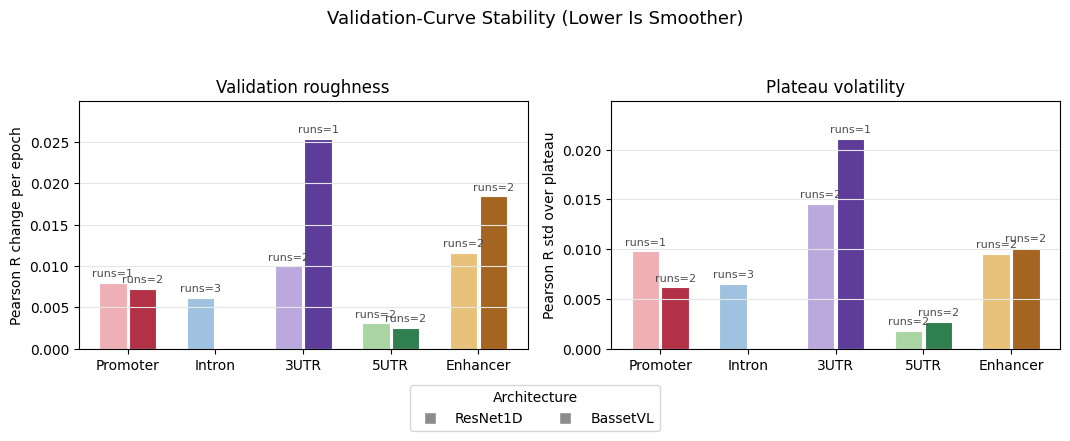

In [46]:
def _numeric_metric_series(history, metric="val_pearson"):
    if history is None or history.empty or metric not in history.columns:
        return pd.DataFrame(columns=["epoch", metric])
    series = history[["epoch", metric]].copy()
    series["epoch"] = pd.to_numeric(series["epoch"], errors="coerce")
    series[metric] = pd.to_numeric(series[metric], errors="coerce")
    series = series.dropna(subset=["epoch", metric]).sort_values("epoch")
    if series.empty:
        return series
    return series.groupby("epoch", as_index=False).agg({metric: "last"}).sort_values("epoch")


def validation_curve_stability_metrics(
    history,
    metric="val_pearson",
    plateau_window=20,
    plateau_fraction=0.25,
    min_epochs=5,
    large_jump_threshold=0.02,
):
    """Return per-run smoothness diagnostics for one validation metric history."""
    series_df = _numeric_metric_series(history, metric=metric)
    n_epochs = int(len(series_df))
    base = {
        "metric": metric,
        "n_metric_epochs": n_epochs,
        "curve_first_epoch": np.nan,
        "curve_last_epoch": np.nan,
        "curve_best_epoch": np.nan,
        "curve_best_value": np.nan,
        "curve_final_value": np.nan,
        "roughness_mean_abs_delta": np.nan,
        "roughness_median_abs_delta": np.nan,
        "roughness_p95_abs_delta": np.nan,
        "roughness_delta_std": np.nan,
        "large_jump_count": np.nan,
        "large_jump_fraction": np.nan,
        "monotone_up_fraction": np.nan,
        "best_final_gap": np.nan,
        "first_epoch_to_95pct_best": np.nan,
        "epoch_fraction_to_95pct_best": np.nan,
        "plateau_start_epoch": np.nan,
        "plateau_n_epochs": 0,
        "plateau_value_mean": np.nan,
        "plateau_value_std": np.nan,
        "plateau_roughness_mean_abs_delta": np.nan,
    }
    if n_epochs == 0:
        return base

    epochs = series_df["epoch"].to_numpy(dtype=float)
    values = series_df[metric].to_numpy(dtype=float)
    base.update({
        "curve_first_epoch": float(epochs[0]),
        "curve_last_epoch": float(epochs[-1]),
        "curve_best_epoch": float(epochs[int(np.nanargmax(values))]),
        "curve_best_value": float(np.nanmax(values)),
        "curve_final_value": float(values[-1]),
        "best_final_gap": float(np.nanmax(values) - values[-1]),
    })
    if n_epochs < min_epochs:
        return base

    deltas = np.diff(values)
    abs_deltas = np.abs(deltas)
    if len(abs_deltas):
        base.update({
            "roughness_mean_abs_delta": float(np.nanmean(abs_deltas)),
            "roughness_median_abs_delta": float(np.nanmedian(abs_deltas)),
            "roughness_p95_abs_delta": float(np.nanpercentile(abs_deltas, 95)),
            "roughness_delta_std": float(np.nanstd(deltas, ddof=1)) if len(deltas) > 1 else 0.0,
            "large_jump_count": int(np.nansum(abs_deltas >= large_jump_threshold)),
            "large_jump_fraction": float(np.nanmean(abs_deltas >= large_jump_threshold)),
            "monotone_up_fraction": float(np.nanmean(deltas >= 0)),
        })

    best_value = base["curve_best_value"]
    if np.isfinite(best_value) and best_value > 0:
        hit_mask = values >= 0.95 * best_value
        if np.any(hit_mask):
            hit_epoch = float(epochs[np.argmax(hit_mask)])
            base["first_epoch_to_95pct_best"] = hit_epoch
            span = max(float(epochs[-1] - epochs[0]), 1.0)
            base["epoch_fraction_to_95pct_best"] = float((hit_epoch - epochs[0]) / span)

    plateau_n = int(min(plateau_window, max(3, math.ceil(n_epochs * plateau_fraction))))
    plateau_n = min(plateau_n, n_epochs)
    plateau_values = values[-plateau_n:]
    plateau_epochs = epochs[-plateau_n:]
    plateau_deltas = np.diff(plateau_values)
    base.update({
        "plateau_start_epoch": float(plateau_epochs[0]),
        "plateau_n_epochs": int(plateau_n),
        "plateau_value_mean": float(np.nanmean(plateau_values)),
        "plateau_value_std": float(np.nanstd(plateau_values, ddof=1)) if plateau_n > 1 else 0.0,
        "plateau_roughness_mean_abs_delta": float(np.nanmean(np.abs(plateau_deltas))) if len(plateau_deltas) else 0.0,
    })
    return base


def collect_validation_curve_stability(
    df,
    metric="val_pearson",
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    min_epochs=5,
    plateau_window=20,
    plateau_fraction=0.25,
):
    curve_df = df.copy()
    if regions is not None:
        curve_df = curve_df[curve_df["cre_region"].isin(regions)]
    if include_scopes is not None:
        curve_df = curve_df[curve_df["selection_scope"].isin(include_scopes)]
    curve_df = curve_df[
        curve_df["status"].eq("completed")
        & curve_df["health"].eq("ok")
        & curve_df["run_id"].notna()
    ].copy()

    meta_cols = [
        "run_id", "run_name", "cre_region", "architecture", "run_family", "selection_scope",
        "logger_project", "wandb_sweep_id", "best_epoch", "val_pearson", "test_pearson",
        "train_pearson", "use_reverse_complements", "split_seed", "model_seed", "lr", "weight_decay",
    ]
    meta_cols = [col for col in meta_cols if col in curve_df.columns]
    rows = []
    for _, row in curve_df[meta_cols].drop_duplicates("run_id").iterrows():
        hist, path = load_pearson_history(row["run_id"])
        metrics = validation_curve_stability_metrics(
            hist,
            metric=metric,
            min_epochs=min_epochs,
            plateau_window=plateau_window,
            plateau_fraction=plateau_fraction,
        )
        out = row.to_dict()
        out.update(metrics)
        out["history_found"] = path is not None
        out["history_path"] = str(path) if path is not None else None
        out["stability_ready"] = bool(path is not None and metrics["n_metric_epochs"] >= min_epochs)
        rows.append(out)

    result = pd.DataFrame(rows)
    if result.empty:
        return result
    result["region_order"] = result["cre_region"].map(region_order).fillna(99)
    result["architecture_order"] = result["architecture"].map(architecture_order).fillna(99)
    return result.sort_values(["region_order", "architecture_order", "run_id"]).drop(columns=["region_order", "architecture_order"]).reset_index(drop=True)


def summarize_validation_curve_stability(stability_df):
    ready = stability_df[stability_df["stability_ready"]].copy()
    if ready.empty:
        return pd.DataFrame()
    summary = ready.groupby(["cre_region", "architecture"], dropna=False).agg(
        n_runs_with_history=("run_id", "nunique"),
        median_curve_best_value=("curve_best_value", "median"),
        median_curve_final_value=("curve_final_value", "median"),
        median_roughness=("roughness_mean_abs_delta", "median"),
        q25_roughness=("roughness_mean_abs_delta", lambda s: s.quantile(0.25)),
        q75_roughness=("roughness_mean_abs_delta", lambda s: s.quantile(0.75)),
        median_plateau_volatility=("plateau_value_std", "median"),
        q25_plateau_volatility=("plateau_value_std", lambda s: s.quantile(0.25)),
        q75_plateau_volatility=("plateau_value_std", lambda s: s.quantile(0.75)),
        median_plateau_roughness=("plateau_roughness_mean_abs_delta", "median"),
        median_best_final_gap=("best_final_gap", "median"),
        median_epoch_fraction_to_95pct_best=("epoch_fraction_to_95pct_best", "median"),
        median_large_jump_fraction=("large_jump_fraction", "median"),
    ).reset_index()
    summary["region_order"] = summary["cre_region"].map(region_order).fillna(99)
    summary["architecture_order"] = summary["architecture"].map(architecture_order).fillna(99)
    return summary.sort_values(["region_order", "architecture_order"]).drop(columns=["region_order", "architecture_order"]).reset_index(drop=True)


def history_coverage_by_architecture(stability_df):
    if stability_df.empty:
        return pd.DataFrame()
    coverage = stability_df.groupby(["cre_region", "architecture"], dropna=False).agg(
        n_completed_runs=("run_id", "nunique"),
        n_histories_found=("history_found", "sum"),
        n_stability_ready=("stability_ready", "sum"),
        median_logged_val_epochs=("n_metric_epochs", "median"),
    ).reset_index()
    coverage["history_coverage_fraction"] = coverage["n_histories_found"] / coverage["n_completed_runs"].replace(0, np.nan)
    coverage["region_order"] = coverage["cre_region"].map(region_order).fillna(99)
    coverage["architecture_order"] = coverage["architecture"].map(architecture_order).fillna(99)
    return coverage.sort_values(["region_order", "architecture_order"]).drop(columns=["region_order", "architecture_order"]).reset_index(drop=True)


def plot_validation_curve_stability_summary(
    summary_df,
    metrics=("median_roughness", "median_plateau_volatility"),
    titles=("Validation roughness", "Plateau volatility"),
):
    if summary_df.empty:
        print("No stability-ready histories found. Export local W&B histories first, then rerun this cell.")
        return None, None
    regions = [region for region in FINISHED_ORCHESTRATOR_REGIONS if region in set(summary_df["cre_region"])]
    architectures = [arch for arch in ("ResNet1D", "BassetVL") if arch in set(summary_df["architecture"])]
    x = np.arange(len(regions), dtype=float)
    width = 0.34 if len(architectures) > 1 else 0.52
    offsets = np.linspace(-width / 2, width / 2, len(architectures)) if len(architectures) > 1 else [0.0]

    fig, axes = plt.subplots(1, len(metrics), figsize=(5.4 * len(metrics), 4.2), squeeze=False, sharex=True)
    axes = axes.ravel()
    for ax, metric_col, title in zip(axes, metrics, titles):
        for offset, arch in zip(offsets, architectures):
            heights = []
            labels = []
            colors = []
            for region in regions:
                part = summary_df[(summary_df["cre_region"].eq(region)) & (summary_df["architecture"].eq(arch))]
                if part.empty or metric_col not in part.columns:
                    heights.append(np.nan)
                    labels.append("")
                else:
                    heights.append(float(part[metric_col].iloc[0]))
                    labels.append(f"runs={int(part['n_runs_with_history'].iloc[0])}")
                colors.append(REGION_ARCH_COLORS.get((region, arch), "0.55"))
            bars = ax.bar(x + offset, heights, width=width * 0.92, label=arch, color=colors, edgecolor="white", linewidth=0.8)
            for bar, label, height in zip(bars, labels, heights):
                if label and np.isfinite(height):
                    ax.annotate(label, xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8, color="0.3")
        ax.set_title(title)
        ax.set_ylabel("Pearson R change per epoch" if "roughness" in metric_col else "Pearson R std over plateau")
        ax.set_xticks(x)
        ax.set_xticklabels(regions)
        ax.grid(axis="y", color="0.9", linewidth=0.8)
        ax.margins(y=0.18)
    handles = [plt.Line2D([0], [0], marker="s", linestyle="", color="none", markerfacecolor="0.55", markeredgecolor="white", markersize=9) for _ in architectures]
    fig.legend(
        handles,
        architectures,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        ncol=max(1, len(architectures)),
        frameon=True,
        title="Architecture",
    )
    fig.suptitle("Validation-Curve Stability (Lower Is Smoother)", y=0.98, fontsize=13)
    fig.tight_layout(rect=(0, 0.08, 1, 0.93))
    return fig, axes


curve_stability = collect_validation_curve_stability(
    run_cfg,
    metric="val_pearson",
    min_epochs=5,
    plateau_window=20,
    plateau_fraction=0.25,
)
curve_stability_coverage = history_coverage_by_architecture(curve_stability)
curve_stability_summary = summarize_validation_curve_stability(curve_stability)

display(curve_stability_coverage)
display(curve_stability_summary)

stability_detail_cols = [
    "cre_region", "architecture", "run_id", "run_name", "n_metric_epochs", "curve_best_value",
    "curve_final_value", "roughness_mean_abs_delta", "plateau_value_std", "best_final_gap",
    "large_jump_fraction", "history_found", "history_path",
]
stability_detail_cols = [col for col in stability_detail_cols if col in curve_stability.columns]
display(curve_stability[curve_stability["stability_ready"]][stability_detail_cols].sort_values([
    "cre_region", "architecture", "roughness_mean_abs_delta"
]))

fig_stability, axes_stability = plot_validation_curve_stability_summary(curve_stability_summary)



#### 5UTR And Enhancer Top-Performer Curves

This focused view uses the same validation-selected and max-test diagnostic selection rule as the broader learning-curve audit, restricted to the finished 5'UTR and enhancer orchestrator sweeps.

,inspection_view,combo_label,curve_role,run_id,run_name,cre_region,architecture,run_family,best_epoch,val_pearson,test_pearson,use_reverse_complements,split_seed,model_seed,lr,weight_decay,history_path,history_found
1,5UTR/enhancer architecture,5UTR | BassetVL,max-test diagnostic,a5zoy95n,lib1_fiveprime_modal50_utr_bassetvl_scratch_69...,5UTR,BassetVL,standardized scratch,156,0.451856,0.458869,False,303,1702.0,0.000055,0.000335,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
0,5UTR/enhancer architecture,5UTR | BassetVL,validation-selected,n9lzq306,lib1_fiveprime_modal50_utr_bassetvl_scratch_0i...,5UTR,BassetVL,standardized scratch,151,0.538877,0.344869,True,101,1702.0,0.000061,0.002084,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
3,5UTR/enhancer architecture,5UTR | ResNet1D,max-test diagnostic,yydnds86,lib1_fiveprime_modal50_resnet1d_scratch_tmrktxth,5UTR,ResNet1D,standardized scratch,178,0.468385,0.498117,False,303,1701.0,0.000031,0.000395,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
2,5UTR/enhancer architecture,5UTR | ResNet1D,validation-selected,4a2z7obx,lib1_fiveprime_modal50_resnet1d_scratch_aqf8aku8,5UTR,ResNet1D,standardized scratch,161,0.540936,0.367017,True,101,1702.0,0.000053,0.000032,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
5,5UTR/enhancer architecture,Enhancer | BassetVL,max-test diagnostic,f0e9s0ef,lib1_enhancer_no_flank_hq8_bassetvl_scratch_e8...,Enhancer,BassetVL,standardized scratch,2,0.195890,0.227071,True,202,1702.0,0.000127,0.000287,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
4,5UTR/enhancer architecture,Enhancer | BassetVL,validation-selected,rbdf02tt,lib1_enhancer_no_flank_hq8_bassetvl_scratch_rg...,Enhancer,BassetVL,standardized scratch,62,0.217002,0.136143,False,202,1702.0,0.001240,0.000393,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
7,5UTR/enhancer architecture,Enhancer | ResNet1D,max-test diagnostic,6bfdqog1,lib1_enhancer_no_flank_hq8_resnet1d_scratch_tw...,Enhancer,ResNet1D,standardized scratch,46,0.081115,0.215067,False,101,1702.0,0.000107,0.000102,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True
6,5UTR/enhancer architecture,Enhancer | ResNet1D,validation-selected,xugbiwmk,lib1_enhancer_no_flank_hq8_resnet1d_scratch_0x...,Enhancer,ResNet1D,standardized scratch,64,0.269468,0.181664,True,202,1702.0,0.000056,0.000008,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,True


,run_id,run_name,cre_region,architecture,run_family,use_reverse_complements,best_epoch,val_pearson,test_pearson,curve_roles,inspection_views,combo_labels,history_found,history_path
2,a5zoy95n,lib1_fiveprime_modal50_utr_bassetvl_scratch_69...,5UTR,BassetVL,standardized scratch,False,156,0.451856,0.458869,max-test diagnostic,5UTR/enhancer architecture,5UTR | BassetVL,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
4,n9lzq306,lib1_fiveprime_modal50_utr_bassetvl_scratch_0i...,5UTR,BassetVL,standardized scratch,True,151,0.538877,0.344869,validation-selected,5UTR/enhancer architecture,5UTR | BassetVL,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
7,yydnds86,lib1_fiveprime_modal50_resnet1d_scratch_tmrktxth,5UTR,ResNet1D,standardized scratch,False,178,0.468385,0.498117,max-test diagnostic,5UTR/enhancer architecture,5UTR | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
0,4a2z7obx,lib1_fiveprime_modal50_resnet1d_scratch_aqf8aku8,5UTR,ResNet1D,standardized scratch,True,161,0.540936,0.367017,validation-selected,5UTR/enhancer architecture,5UTR | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
3,f0e9s0ef,lib1_enhancer_no_flank_hq8_bassetvl_scratch_e8...,Enhancer,BassetVL,standardized scratch,True,2,0.195890,0.227071,max-test diagnostic,5UTR/enhancer architecture,Enhancer | BassetVL,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
5,rbdf02tt,lib1_enhancer_no_flank_hq8_bassetvl_scratch_rg...,Enhancer,BassetVL,standardized scratch,False,62,0.217002,0.136143,validation-selected,5UTR/enhancer architecture,Enhancer | BassetVL,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
1,6bfdqog1,lib1_enhancer_no_flank_hq8_resnet1d_scratch_tw...,Enhancer,ResNet1D,standardized scratch,False,46,0.081115,0.215067,max-test diagnostic,5UTR/enhancer architecture,Enhancer | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...
6,xugbiwmk,lib1_enhancer_no_flank_hq8_resnet1d_scratch_0x...,Enhancer,ResNet1D,standardized scratch,True,64,0.269468,0.181664,validation-selected,5UTR/enhancer architecture,Enhancer | ResNet1D,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...


,run_id,run_name,cre_region,architecture,rc_state,best_epoch,history_found,history_path,n_train_epochs,n_val_epochs,n_test_epochs,test_logging
0,a5zoy95n,lib1_fiveprime_modal50_utr_bassetvl_scratch_69...,5UTR,BassetVL,RC off,156,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,203,202,203,per-epoch curve
1,n9lzq306,lib1_fiveprime_modal50_utr_bassetvl_scratch_0i...,5UTR,BassetVL,RC on,151,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,198,197,198,per-epoch curve
3,4a2z7obx,lib1_fiveprime_modal50_resnet1d_scratch_aqf8aku8,5UTR,ResNet1D,RC on,161,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,181,180,181,per-epoch curve
2,yydnds86,lib1_fiveprime_modal50_resnet1d_scratch_tmrktxth,5UTR,ResNet1D,RC off,178,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,181,180,181,per-epoch curve
4,f0e9s0ef,lib1_enhancer_no_flank_hq8_bassetvl_scratch_e8...,Enhancer,BassetVL,RC on,2,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,39,38,39,per-epoch curve
5,rbdf02tt,lib1_enhancer_no_flank_hq8_bassetvl_scratch_rg...,Enhancer,BassetVL,RC off,62,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,99,98,99,per-epoch curve
6,6bfdqog1,lib1_enhancer_no_flank_hq8_resnet1d_scratch_tw...,Enhancer,ResNet1D,RC off,46,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,83,82,83,per-epoch curve
7,xugbiwmk,lib1_enhancer_no_flank_hq8_resnet1d_scratch_0x...,Enhancer,ResNet1D,RC on,64,True,/home/minhang/synBio_AL/boda2_EU/src/learn/run...,101,100,101,per-epoch curve


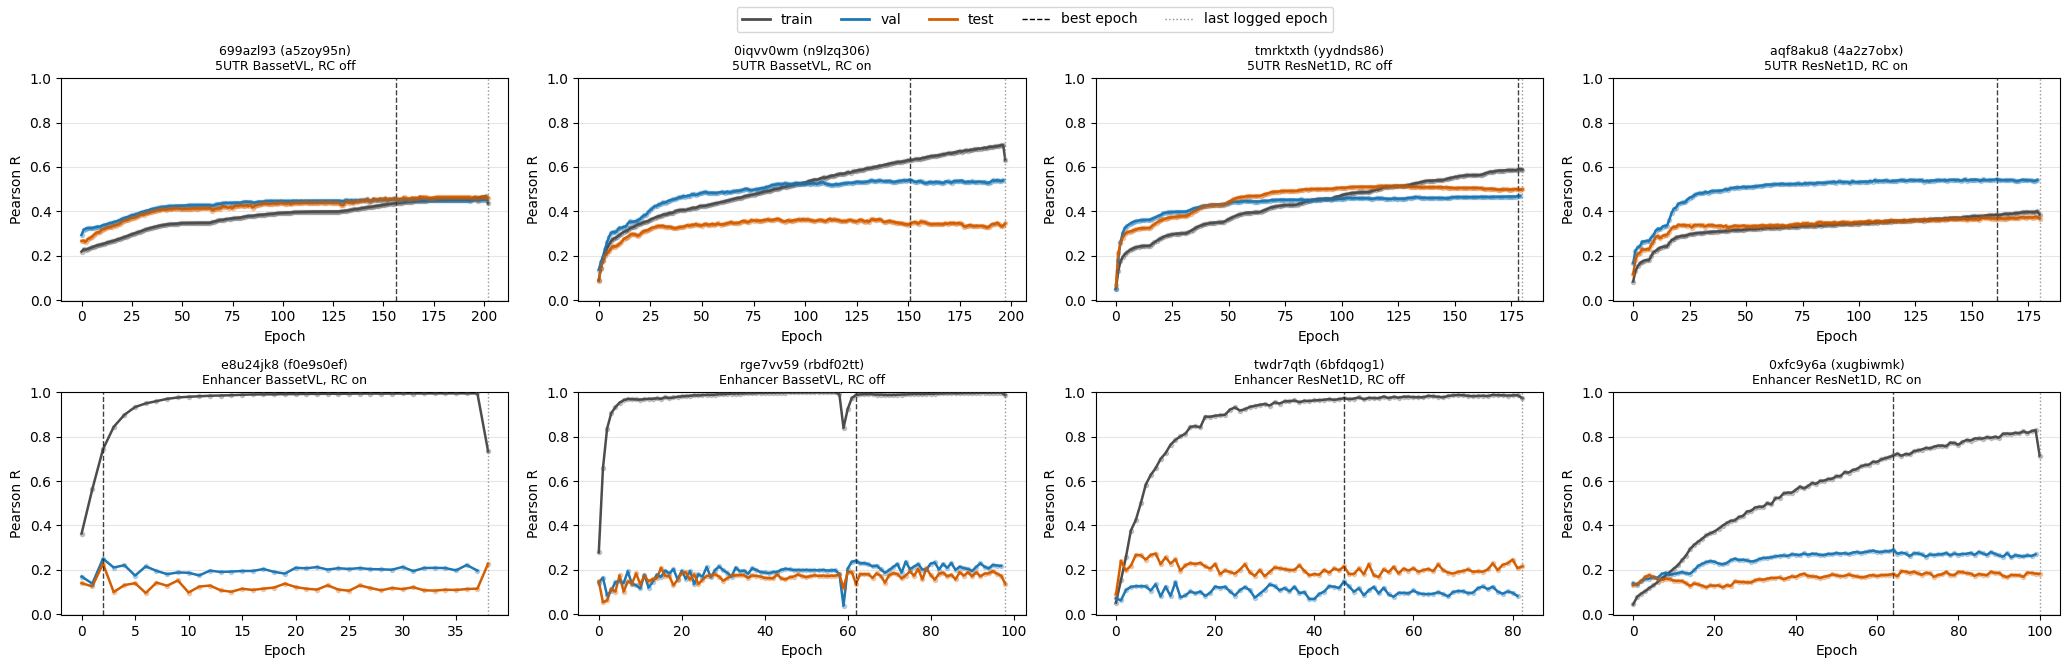

In [47]:
def collect_top_performer_runs_for_regions(df, regions=("5UTR", "Enhancer")):
    group_by = ("cre_region", "architecture")
    rank_df = validation_selected_outcome_rank(
        df,
        selection_metric="val_pearson",
        outcome_metric="test_pearson",
        group_by=group_by,
        regions=regions,
        architectures=None,
        include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    )
    rows = []
    for _, row in rank_df.iterrows():
        combo_label = combo_label_from_row(row, group_by)
        rows.append({
            "inspection_view": "5UTR/enhancer architecture",
            "combo_label": combo_label,
            "curve_role": "validation-selected",
            "run_id": row["selected_run_id"],
        })
        rows.append({
            "inspection_view": "5UTR/enhancer architecture",
            "combo_label": combo_label,
            "curve_role": "max-test diagnostic",
            "run_id": row["max_outcome_run_id"],
        })

    highlight = pd.DataFrame(rows).drop_duplicates()
    run_meta_cols = [
        "run_id", "run_name", "cre_region", "architecture", "run_family", "best_epoch",
        "val_pearson", "test_pearson", "use_reverse_complements", "split_seed", "model_seed", "lr", "weight_decay",
    ]
    run_meta_cols = [col for col in run_meta_cols if col in df.columns]
    meta = df[run_meta_cols].drop_duplicates("run_id")
    highlight = highlight.merge(meta, on="run_id", how="left")
    highlight["history_path"] = highlight["run_id"].map(lambda run_id: str(history_path_for_run(run_id)) if history_path_for_run(run_id) else None)
    highlight["history_found"] = highlight["history_path"].notna()

    summary = highlight.groupby("run_id", as_index=False).agg(
        run_name=("run_name", "first"),
        cre_region=("cre_region", "first"),
        architecture=("architecture", "first"),
        run_family=("run_family", "first"),
        use_reverse_complements=("use_reverse_complements", "first"),
        best_epoch=("best_epoch", "first"),
        val_pearson=("val_pearson", "first"),
        test_pearson=("test_pearson", "first"),
        curve_roles=("curve_role", lambda s: ", ".join(sorted(set(s)))),
        inspection_views=("inspection_view", lambda s: "; ".join(sorted(set(s)))),
        combo_labels=("combo_label", lambda s: "; ".join(sorted(set(s)))),
        history_found=("history_found", "max"),
        history_path=("history_path", lambda s: next((x for x in s if pd.notna(x)), None)),
    )
    return (
        highlight.sort_values(["cre_region", "architecture", "combo_label", "curve_role"]),
        summary.sort_values(["cre_region", "architecture", "curve_roles", "run_id"]),
    )


utr5_enhancer_top_table, utr5_enhancer_curve_runs = collect_top_performer_runs_for_regions(run_cfg)
display(utr5_enhancer_top_table)
display(utr5_enhancer_curve_runs)

utr5_enhancer_metric_counts = history_metric_counts(utr5_enhancer_curve_runs)
display(utr5_enhancer_metric_counts)

fig_utr5_enhancer, axes_utr5_enhancer = plot_learning_curve_grid(utr5_enhancer_curve_runs, ncols=4)


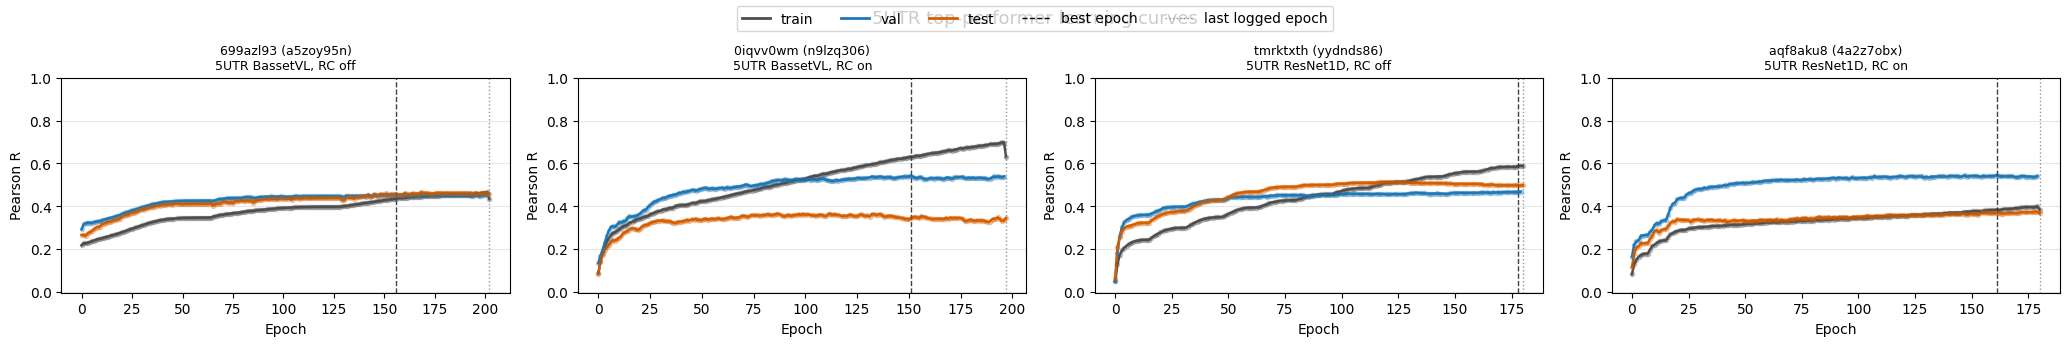

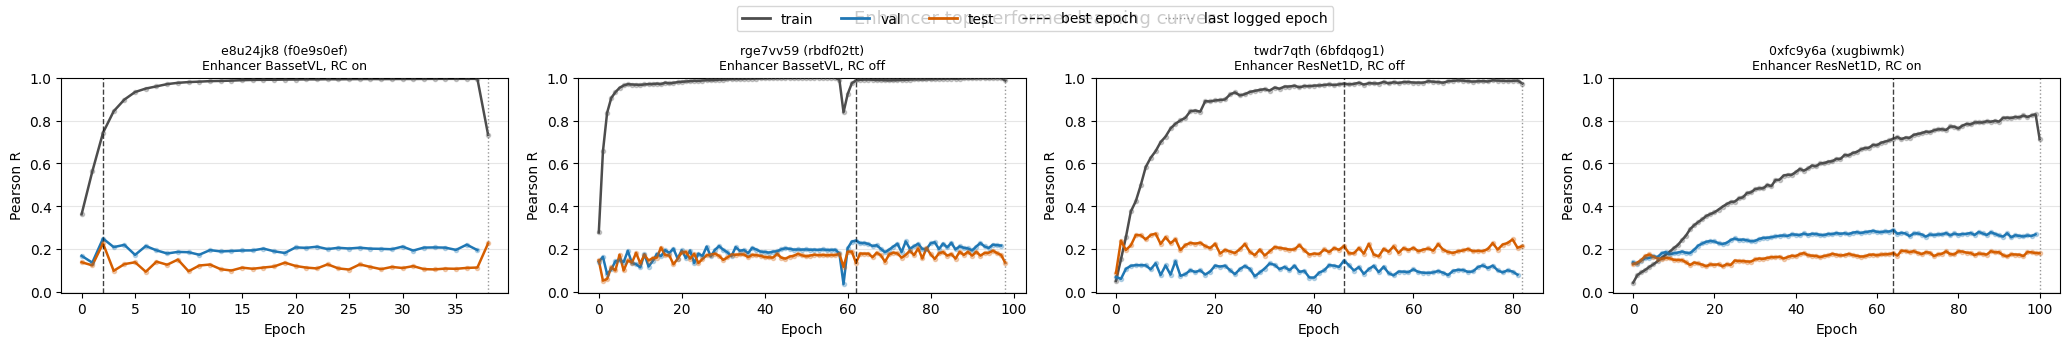

In [48]:
utr5_enhancer_region_figures = {}
utr5_enhancer_region_axes = {}

shared_utr5_enhancer_ylim = pearson_ylim_for_histories(
    utr5_enhancer_curve_runs[utr5_enhancer_curve_runs["history_found"]]
)

for cre_region, region_runs in utr5_enhancer_curve_runs.groupby("cre_region", sort=False):
    region_runs = region_runs.sort_values(["architecture", "curve_roles", "run_id"])
    fig, axes = plot_learning_curve_grid(
        region_runs,
        ncols=4,
        y_limits=shared_utr5_enhancer_ylim,
    )
    if fig is not None:
        fig.suptitle(f"{cre_region} top-performer learning curves", y=1.02, fontsize=13)
    utr5_enhancer_region_figures[cre_region] = fig
    utr5_enhancer_region_axes[cre_region] = axes


## RC Augmentation And Metric Naming Audit

Reverse-complement augmentation is audited within each `CRE region x architecture` slice, which is the fairest comparison available from these HPO sweeps. The tables below still are not causal estimates: RC state was sampled together with split seed, model seed, and other hyperparameters. Treat the RC-on-minus-RC-off deltas as screening evidence for follow-up, not as a paired ablation. `fp32` is treated as audit metadata rather than a plot label; old non-fp32 3UTR diagnostic runs remain excluded from the completed-orchestrator selection slice.

,cre_region,architecture,rc_state,n_runs,n_split_seeds,n_model_seeds,val_pearson_median,val_pearson_q25,val_pearson_q75,val_pearson_max,test_pearson_median,test_pearson_q25,test_pearson_q75,test_pearson_max,selected_run_id,selected_val_pearson,selected_test_pearson,test_pearson_rank_desc,max_outcome_run_id,max_test_pearson,test_pearson_gap_to_max,val_minus_test_median,train_minus_test_median
0,Promoter,ResNet1D,RC off,59,1,0,0.285637,0.258064,0.318147,0.375282,0.282037,0.263322,0.295183,0.360312,dx9zn5ky,0.375282,0.242609,51,rn0q2vl4,0.360312,0.117703,-0.004332,0.178103
1,Promoter,ResNet1D,RC on,67,1,0,0.300607,0.266050,0.324755,0.387018,0.315551,0.291906,0.331187,0.385108,ilde84kd,0.387018,0.308844,39,4oycxxgu,0.385108,0.076264,-0.019738,0.171767
2,Promoter,BassetVL,RC off,108,1,0,0.391521,0.377535,0.405269,0.425197,0.334940,0.318283,0.346963,0.391424,cqg85h6j,0.425197,0.350152,24,n0ersfw2,0.391424,0.041272,0.062982,0.087044
3,Promoter,BassetVL,RC on,20,1,0,0.355923,0.346485,0.362482,0.376705,0.321790,0.288966,0.337065,0.353899,sji99nln,0.376705,0.342901,4,88nbpj5i,0.353899,0.010998,0.042077,0.031389
4,Intron,ResNet1D,RC off,57,1,0,0.538526,0.508073,0.578024,0.612131,0.630655,0.611603,0.671448,0.718182,n1lgjs2h,0.612131,0.610603,45,qwnji00w,0.718182,0.107579,-0.104861,-0.112557
5,Intron,ResNet1D,RC on,69,1,0,0.496400,0.470996,0.545502,0.613275,0.660606,0.640624,0.677508,0.701777,glgcweci,0.613275,0.654137,40,dzhn934e,0.701777,0.047639,-0.153500,-0.128577
6,3UTR,ResNet1D,RC off,127,4,0,0.249745,0.165077,0.294281,0.455851,0.212951,0.150331,0.293099,0.477185,8xcp9her,0.455851,0.085764,114,39glhfll,0.477185,0.391421,0.014262,0.138953
7,3UTR,BassetVL,RC off,128,3,0,0.162180,0.113802,0.210626,0.335262,0.086479,0.027053,0.174203,0.586879,utc3cqzn,0.335262,0.281119,10,pn50zxhm,0.586879,0.305760,0.070992,0.424727
8,5UTR,ResNet1D,RC off,103,3,2,0.418967,0.367562,0.453634,0.515443,0.393668,0.364792,0.439973,0.498117,sj1fzyge,0.515443,0.394435,49,yydnds86,0.498117,0.103681,0.009070,0.086399
9,5UTR,ResNet1D,RC on,25,3,2,0.387222,0.300077,0.423777,0.540936,0.360189,0.344714,0.396519,0.420742,4a2z7obx,0.540936,0.367017,10,w0qd8qqj,0.420742,0.053725,-0.006458,0.019792


,cre_region,architecture,n_runs_off,n_runs_on,selected_run_id_off,selected_run_id_on,selected_test_pearson_off,selected_test_pearson_on,selected_test_pearson_on_minus_off,test_pearson_median_off,test_pearson_median_on,test_pearson_median_on_minus_off,test_pearson_max_off,test_pearson_max_on,test_pearson_max_on_minus_off,val_pearson_median_on_minus_off,val_minus_test_median_on_minus_off,train_minus_test_median_on_minus_off
0,Promoter,ResNet1D,59,67.0,dx9zn5ky,ilde84kd,0.242609,0.308844,0.066235,0.282037,0.315551,0.033514,0.360312,0.385108,0.024796,0.014970,-0.015406,-0.006336
1,Promoter,BassetVL,108,20.0,cqg85h6j,sji99nln,0.350152,0.342901,-0.007251,0.334940,0.321790,-0.013150,0.391424,0.353899,-0.037525,-0.035598,-0.020905,-0.055656
2,Intron,ResNet1D,57,69.0,n1lgjs2h,glgcweci,0.610603,0.654137,0.043535,0.630655,0.660606,0.029951,0.718182,0.701777,-0.016405,-0.042125,-0.048638,-0.016020
3,3UTR,ResNet1D,127,NaN,8xcp9her,NaN,0.085764,NaN,NaN,0.212951,NaN,NaN,0.477185,NaN,NaN,NaN,NaN,NaN
4,3UTR,BassetVL,128,NaN,utc3cqzn,NaN,0.281119,NaN,NaN,0.086479,NaN,NaN,0.586879,NaN,NaN,NaN,NaN,NaN
5,5UTR,ResNet1D,103,25.0,sj1fzyge,4a2z7obx,0.394435,0.367017,-0.027418,0.393668,0.360189,-0.033479,0.498117,0.420742,-0.077374,-0.031745,-0.015528,-0.066607
6,5UTR,BassetVL,16,112.0,ugdlv1pm,n9lzq306,0.393631,0.344869,-0.048762,0.382398,0.365358,-0.017040,0.458869,0.433253,-0.025616,0.009845,0.042625,-0.110562
7,Enhancer,ResNet1D,41,87.0,jp037quh,xugbiwmk,0.034993,0.181664,0.146671,0.103869,0.110571,0.006702,0.215067,0.208134,-0.006933,0.002546,0.016502,0.004766
8,Enhancer,BassetVL,86,41.0,rbdf02tt,f0e9s0ef,0.136143,0.227071,0.090928,0.082712,0.078809,-0.003903,0.200820,0.227071,0.026251,-0.017959,-0.035248,-0.033613


,project_detail,best_metric_name,n_runs,invalid_runs
0,3UTR BassetVL,val_pearson,160,0
1,3UTR BassetVL (focused RC grid),val_pearson,128,0
2,3UTR ResNet1D,val_pearson,159,0
3,3UTR ResNet1D (legacy precision diagnostic),val_pearson,31,10
4,5UTR BassetVL,val_pearson,192,0
5,5UTR ResNet1D,val_pearson,192,0
6,Enhancer BassetVL,val_pearson,129,0
7,Enhancer ResNet1D,val_pearson,130,0
8,Intron ResNet1D,val_pearson,158,0
9,Promoter BassetVL,val_pearson,176,0


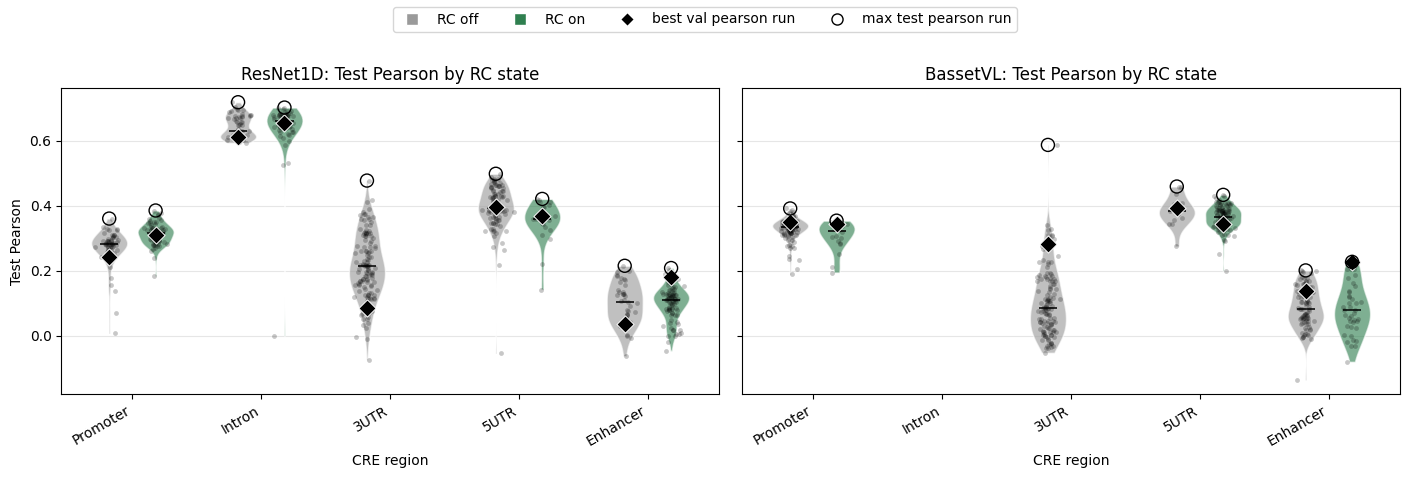

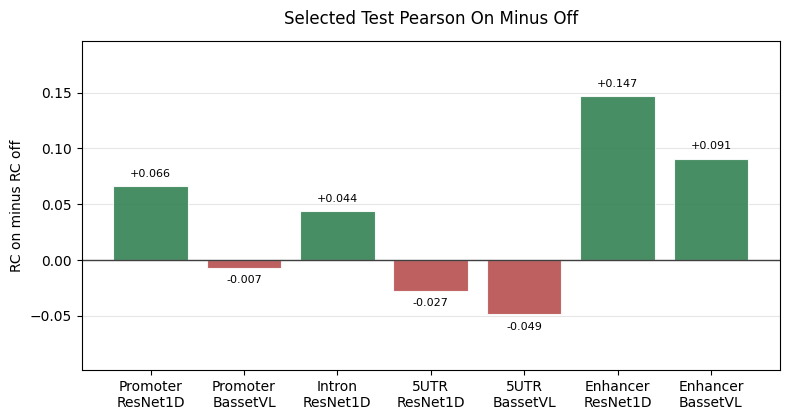

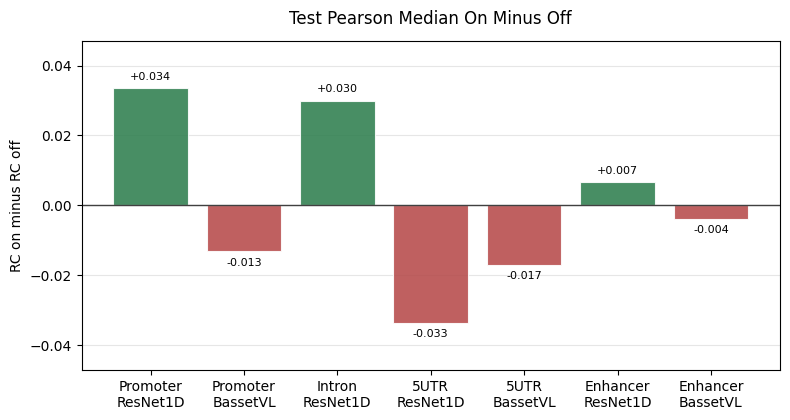

In [49]:
rc_ready = run_cfg[
    run_cfg["selection_ready"]
    & run_cfg["config_found"]
    & run_cfg["selection_scope"].isin(ORCHESTRATOR_ANALYSIS_SCOPES)
].copy()
rc_ready["use_reverse_complements"] = rc_ready["use_reverse_complements"].map(normalize_bool)
rc_ready = rc_ready[rc_ready["use_reverse_complements"].notna()].copy()
rc_ready["rc_state"] = rc_ready["use_reverse_complements"]
rc_ready["rc_label"] = rc_ready["rc_state"].map(rc_label)
rc_ready["val_minus_test_pearson"] = rc_ready["val_pearson"] - rc_ready["test_pearson"]
rc_ready["train_minus_val_pearson"] = rc_ready["train_pearson"] - rc_ready["val_pearson"]
rc_ready["train_minus_test_pearson"] = rc_ready["train_pearson"] - rc_ready["test_pearson"]

rc_group_cols = ["cre_region", "architecture", "use_reverse_complements"]
rc_selected_rank = validation_selected_outcome_rank(
    rc_ready,
    selection_metric="val_pearson",
    outcome_metric="test_pearson",
    group_by=tuple(rc_group_cols),
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
)

rc_arch_summary = rc_ready.groupby(rc_group_cols, dropna=False).agg(
    n_runs=("run_id", "nunique"),
    n_split_seeds=("split_seed", "nunique"),
    n_model_seeds=("model_seed", "nunique"),
    val_pearson_median=("val_pearson", "median"),
    val_pearson_q25=("val_pearson", lambda s: s.quantile(0.25)),
    val_pearson_q75=("val_pearson", lambda s: s.quantile(0.75)),
    val_pearson_max=("val_pearson", "max"),
    test_pearson_median=("test_pearson", "median"),
    test_pearson_q25=("test_pearson", lambda s: s.quantile(0.25)),
    test_pearson_q75=("test_pearson", lambda s: s.quantile(0.75)),
    test_pearson_max=("test_pearson", "max"),
    train_pearson_median=("train_pearson", "median"),
    val_minus_test_median=("val_minus_test_pearson", "median"),
    train_minus_test_median=("train_minus_test_pearson", "median"),
).reset_index()
rc_arch_summary = rc_arch_summary.merge(
    rc_selected_rank[[
        *rc_group_cols,
        "selected_run_id", "selected_val_pearson", "selected_test_pearson",
        "test_pearson_rank_desc", "test_pearson_percentile",
        "max_outcome_run_id", "max_test_pearson", "test_pearson_gap_to_max",
    ]],
    on=rc_group_cols,
    how="left",
)
rc_arch_summary["rc_state"] = rc_arch_summary["use_reverse_complements"].map(rc_label)
rc_arch_summary["region_order"] = rc_arch_summary["cre_region"].map(region_order).fillna(99)
rc_arch_summary["architecture_order"] = rc_arch_summary["architecture"].map(architecture_order).fillna(99)
rc_arch_summary = rc_arch_summary.sort_values([
    "region_order", "architecture_order", "use_reverse_complements",
]).drop(columns=["region_order", "architecture_order"]).reset_index(drop=True)

rc_summary_display_cols = [
    "cre_region", "architecture", "rc_state", "n_runs", "n_split_seeds", "n_model_seeds",
    "val_pearson_median", "val_pearson_q25", "val_pearson_q75", "val_pearson_max",
    "test_pearson_median", "test_pearson_q25", "test_pearson_q75", "test_pearson_max",
    "selected_run_id", "selected_val_pearson", "selected_test_pearson", "test_pearson_rank_desc",
    "max_outcome_run_id", "max_test_pearson", "test_pearson_gap_to_max",
    "val_minus_test_median", "train_minus_test_median",
]
display(rc_arch_summary[rc_summary_display_cols])


def rc_on_minus_off_table(summary):
    metric_cols = [
        "n_runs", "val_pearson_median", "val_pearson_max", "test_pearson_median", "test_pearson_max",
        "selected_val_pearson", "selected_test_pearson", "max_test_pearson",
        "val_minus_test_median", "train_minus_test_median",
    ]
    rows = []
    for (region, architecture), part in summary.groupby(["cre_region", "architecture"], dropna=False):
        off = part[part["use_reverse_complements"].eq(False)]
        on = part[part["use_reverse_complements"].eq(True)]
        row = {"cre_region": region, "architecture": architecture}
        for state_label, state_df in [("off", off), ("on", on)]:
            for col in ["n_runs", "selected_run_id", "max_outcome_run_id"]:
                row[f"{col}_{state_label}"] = state_df[col].iloc[0] if not state_df.empty else np.nan
        for metric in metric_cols:
            off_value = pd.to_numeric(off[metric], errors="coerce").iloc[0] if not off.empty else np.nan
            on_value = pd.to_numeric(on[metric], errors="coerce").iloc[0] if not on.empty else np.nan
            row[f"{metric}_off"] = off_value
            row[f"{metric}_on"] = on_value
            row[f"{metric}_on_minus_off"] = on_value - off_value if pd.notna(on_value) and pd.notna(off_value) else np.nan
        rows.append(row)
    result = pd.DataFrame(rows)
    result["region_order"] = result["cre_region"].map(region_order).fillna(99)
    result["architecture_order"] = result["architecture"].map(architecture_order).fillna(99)
    return result.sort_values(["region_order", "architecture_order"]).drop(columns=["region_order", "architecture_order"]).reset_index(drop=True)


rc_arch_delta = rc_on_minus_off_table(rc_arch_summary)
rc_delta_display_cols = [
    "cre_region", "architecture", "n_runs_off", "n_runs_on",
    "selected_run_id_off", "selected_run_id_on",
    "selected_test_pearson_off", "selected_test_pearson_on", "selected_test_pearson_on_minus_off",
    "test_pearson_median_off", "test_pearson_median_on", "test_pearson_median_on_minus_off",
    "test_pearson_max_off", "test_pearson_max_on", "test_pearson_max_on_minus_off",
    "val_pearson_median_on_minus_off", "val_minus_test_median_on_minus_off", "train_minus_test_median_on_minus_off",
]
display(rc_arch_delta[rc_delta_display_cols])


def plot_rc_distribution_by_architecture(
    df,
    rank_df,
    metric="test_pearson",
    selection_metric="val_pearson",
    architectures=("ResNet1D", "BassetVL"),
):
    plot_df = df[df["architecture"].isin(architectures)].copy()
    regions = [region for region in FINISHED_ORCHESTRATOR_REGIONS if region in set(plot_df["cre_region"])]
    fig, axes = plt.subplots(1, len(architectures), figsize=(7.1 * len(architectures), 4.8), sharey=True)
    axes = np.atleast_1d(axes)
    rc_offsets = {False: -0.18, True: 0.18}
    rc_colors = {False: "#9a9a9a", True: "#2f7f4f"}
    rng = np.random.default_rng(13)

    for ax, architecture in zip(axes, architectures):
        arch_df = plot_df[plot_df["architecture"].eq(architecture)]
        for x_idx, region in enumerate(regions):
            for rc_state in [False, True]:
                part = arch_df[
                    arch_df["cre_region"].eq(region)
                    & arch_df["use_reverse_complements"].eq(rc_state)
                    & arch_df[metric].notna()
                ]
                if part.empty:
                    continue
                pos = x_idx + rc_offsets[rc_state]
                values = part[metric].to_numpy(dtype=float)
                if len(values) > 1 and np.nanmax(values) > np.nanmin(values):
                    viol = ax.violinplot(
                        [values], positions=[pos], widths=0.28,
                        showmeans=False, showmedians=True, showextrema=False,
                    )
                    for body in viol["bodies"]:
                        body.set_facecolor(rc_colors[rc_state])
                        body.set_edgecolor("white")
                        body.set_alpha(0.62)
                    viol["cmedians"].set_color("black")
                    viol["cmedians"].set_linewidth(1.1)
                jitter = rng.normal(0, 0.035, size=len(values))
                ax.scatter(
                    np.full(len(values), pos) + jitter,
                    values,
                    s=12, color="black", alpha=0.22, linewidths=0, zorder=3,
                )
                marker_row = rank_df[
                    rank_df["cre_region"].eq(region)
                    & rank_df["architecture"].eq(architecture)
                    & rank_df["use_reverse_complements"].eq(rc_state)
                ]
                if not marker_row.empty:
                    marker_row = marker_row.iloc[0]
                    ax.scatter(
                        pos, marker_row[f"selected_{metric}"],
                        marker="D", s=76, color="black", edgecolors="white", linewidths=0.7, zorder=5,
                    )
                    ax.scatter(
                        pos, marker_row[f"max_{metric}"],
                        marker="o", s=88, facecolors="none", edgecolors="black", linewidths=1.0, zorder=5,
                    )
        ax.set_title(f"{architecture}: {metric.replace('_', ' ').title()} by RC state")
        ax.set_xticks(np.arange(len(regions)))
        ax.set_xticklabels(regions, rotation=30, ha="right")
        ax.set_xlabel("CRE region")
        ax.grid(axis="y", color="0.9", linewidth=0.8)
        ax.set_axisbelow(True)
    axes[0].set_ylabel(metric.replace("_", " ").title())
    handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", color="none", markerfacecolor="#9a9a9a", markeredgecolor="white", markersize=9),
        plt.Line2D([0], [0], marker="s", linestyle="", color="none", markerfacecolor="#2f7f4f", markeredgecolor="white", markersize=9),
        plt.Line2D([0], [0], marker="D", linestyle="", color="black", markeredgecolor="white", markersize=7),
        plt.Line2D([0], [0], marker="o", linestyle="", color="black", markerfacecolor="none", markersize=8),
    ]
    labels = ["RC off", "RC on", f"best {selection_metric.replace('_', ' ')} run", f"max {metric.replace('_', ' ')} run"]
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=True)
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig, axes


def plot_rc_delta_bars(delta_df, metric="selected_test_pearson_on_minus_off"):
    plot_df = delta_df[pd.to_numeric(delta_df[metric], errors="coerce").notna()].copy()
    plot_df[metric] = pd.to_numeric(plot_df[metric], errors="coerce")
    plot_df["label"] = plot_df["cre_region"] + "\n" + plot_df["architecture"]
    colors = np.where(plot_df[metric].ge(0), "#2f7f4f", "#b64a4a")
    fig, ax = plt.subplots(figsize=(max(8.0, 0.92 * len(plot_df)), 4.3))
    x = np.arange(len(plot_df))
    ax.bar(x, plot_df[metric], color=colors, alpha=0.88, edgecolor="white", linewidth=0.8)
    ax.axhline(0, color="0.25", linewidth=1)

    y_min = float(plot_df[metric].min())
    y_max = float(plot_df[metric].max())
    span = max(abs(y_min), abs(y_max), 0.04)
    ax.set_ylim(min(y_min - 0.34 * span, -0.16 * span), max(y_max + 0.34 * span, 0.16 * span))
    label_offset = 0.045 * span
    for xpos, value in zip(x, plot_df[metric]):
        va = "bottom" if value >= 0 else "top"
        offset = label_offset if value >= 0 else -label_offset
        ax.text(xpos, value + offset, f"{value:+.3f}", ha="center", va=va, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["label"], rotation=0)
    ax.set_ylabel("RC on minus RC off")
    ax.set_title(metric.replace("_", " ").title(), pad=12)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig, ax


fig, axes = plot_rc_distribution_by_architecture(rc_ready, rc_selected_rank, metric="test_pearson")
fig_delta, ax_delta = plot_rc_delta_bars(rc_arch_delta, metric="selected_test_pearson_on_minus_off")
fig_delta_median, ax_delta_median = plot_rc_delta_bars(rc_arch_delta, metric="test_pearson_median_on_minus_off")

metric_name_audit = completed_subset.groupby(["project_detail", "best_metric_name"], dropna=False).agg(
    n_runs=("run_id", "nunique"),
    invalid_runs=("invalid_pearson", "sum"),
).reset_index().sort_values(["project_detail", "best_metric_name"])
display(metric_name_audit)


## Working Decision Notes

- Primary selection now uses only completed rows from the full orchestrator sweeps across promoter, intron, 3'UTR, 5'UTR, and enhancer.
- Promoter: compare BassetVL versus ResNet1D on the same orchestrator slice; validation-first selection remains the rule.
- Intron: modal80 ResNet1D scratch remains strong, but the current standardized full orchestrator only covered ResNet1D for intron.
- 3UTR: the completed full orchestrator has both ResNet1D and UTR_BassetVL fp32 sweeps. Use the prior/follow-up grids only as diagnostics unless explicitly reintroduced into the selection slice.
- 5UTR and enhancer: full orchestrator rows are now included in the main completed-orchestrator figures and tables.
- Split diagnostics: promoter and intron currently use one heldout split seed; 3UTR uses four; 5UTR and enhancer use three. For final claims that depend on small performance deltas, rerun selected configurations across additional split seeds.
- Metric naming: prefer `val_pearson`, `test_pearson`, `*_pearson_r2`, `*_cod_r2`, `*_mse`, and keep legacy aliases visible but normalized in analysis.


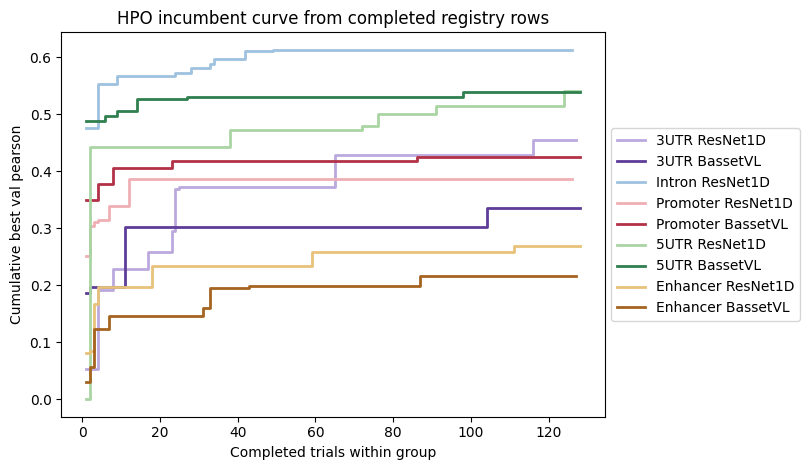

In [50]:
def plot_hpo_incumbent(
    df,
    metric="val_pearson",
    regions=FINISHED_ORCHESTRATOR_REGIONS,
    include_scopes=ORCHESTRATOR_ANALYSIS_SCOPES,
    ax=None,
):
    plot_df = df.copy()
    if regions is not None:
        plot_df = plot_df[plot_df["cre_region"].isin(regions)]
    if include_scopes is not None:
        plot_df = plot_df[plot_df["selection_scope"].isin(include_scopes)]
    plot_df = plot_df[
        plot_df["status"].eq("completed")
        & plot_df["health"].eq("ok")
        & plot_df[metric].notna()
    ].copy()
    plot_df["timestamp_dt"] = pd.to_datetime(plot_df["timestamp"], errors="coerce")
    plot_df = plot_df.dropna(subset=["timestamp_dt"])

    if ax is None:
        fig, ax = plt.subplots(figsize=(8.2, 4.8))
    else:
        fig = ax.figure

    for (region, arch), part in plot_df.groupby(["cre_region", "architecture"], sort=False):
        part = part.sort_values("timestamp_dt")
        incumbent = part[metric].cummax().reset_index(drop=True)
        x = np.arange(1, len(incumbent) + 1)
        ax.step(
            x, incumbent,
            where="post",
            label=f"{region} {arch}",
            color=REGION_ARCH_COLORS.get((region, arch), "0.45"),
            linewidth=2,
        )

    ax.set_xlabel("Completed trials within group")
    ax.set_ylabel(f"Cumulative best {metric.replace('_', ' ')}")
    ax.set_title("HPO incumbent curve from completed registry rows")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=True)
    return fig, ax


fig, ax = plot_hpo_incumbent(selection_subset, metric="val_pearson")
fig.tight_layout()
